In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Test accuracy: 64.31%
Precision: 0.64
Recall: 0.64
F1 Score: 0.64
Results saved to /content/drive/MyDrive/work2/Final/evaluation_results.csv


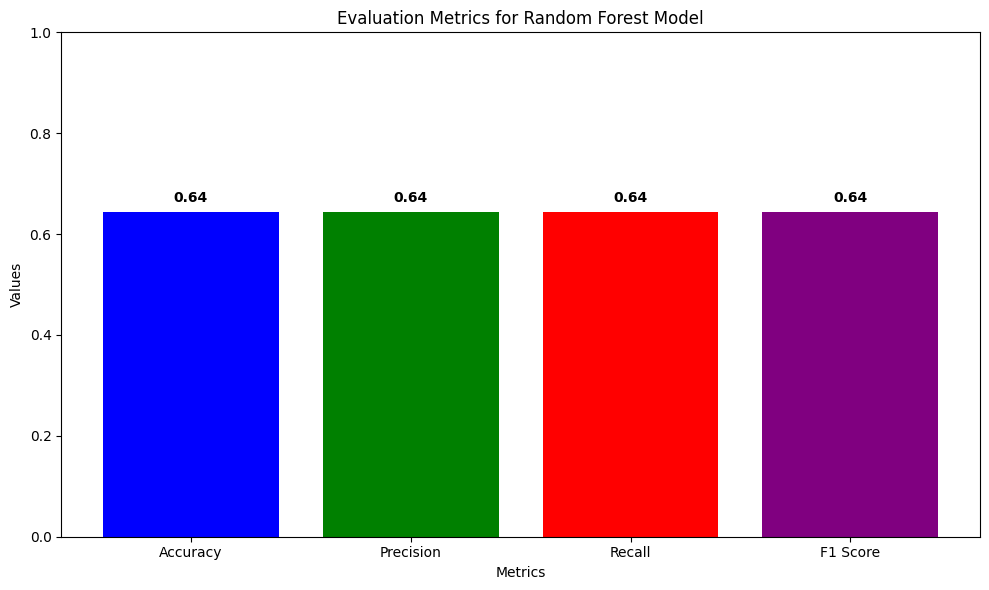

In [13]:
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from skimage.feature import hog
import joblib
import os
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/work2/Final/Final_Image_File/expanded_transcription_results_with_frames.csv')

# Function to preprocess images
def preprocess_image(filepath):
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
    img = cv2.imread(filepath)
    if img is None:
        print(f"Failed to read image: {filepath}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (128, 128))
    img = cv2.equalizeHist(img)
    return img

# Apply preprocessing to each image and prepare labels
images = []
labels = []
for idx, fp in enumerate(df['Frame Path']):
    processed_img = preprocess_image(fp)
    if processed_img is not None:
        images.append(processed_img)
        labels.append(df['Frame Senti'][idx])

images = np.array(images)
labels = np.array(labels)

# Extract HOG features from the images
hog_features = [hog(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys') for image in images]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(hog_features, labels, test_size=0.3, random_state=42)

# Load the saved model
joblib_file = "/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_2_random_forest_model.pkl"
loaded_rf_model = joblib.load(joblib_file)

# Evaluate the model
y_pred = loaded_rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f"Test accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['Random Forest'],
    'Model Path': [joblib_file],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Save the DataFrame to a CSV file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")

# Plot evaluation metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(10, 6))
plt.bar(metrics, values, color=['blue', 'green', 'red', 'purple'])
plt.ylim(0, 1)
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Evaluation Metrics for Random Forest Model')
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/work2/Final/evaluation_metrics_graph.png')
plt.show()


<Figure size 1000x1000 with 0 Axes>

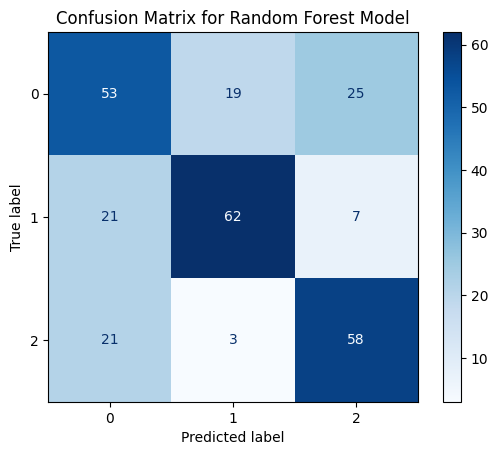

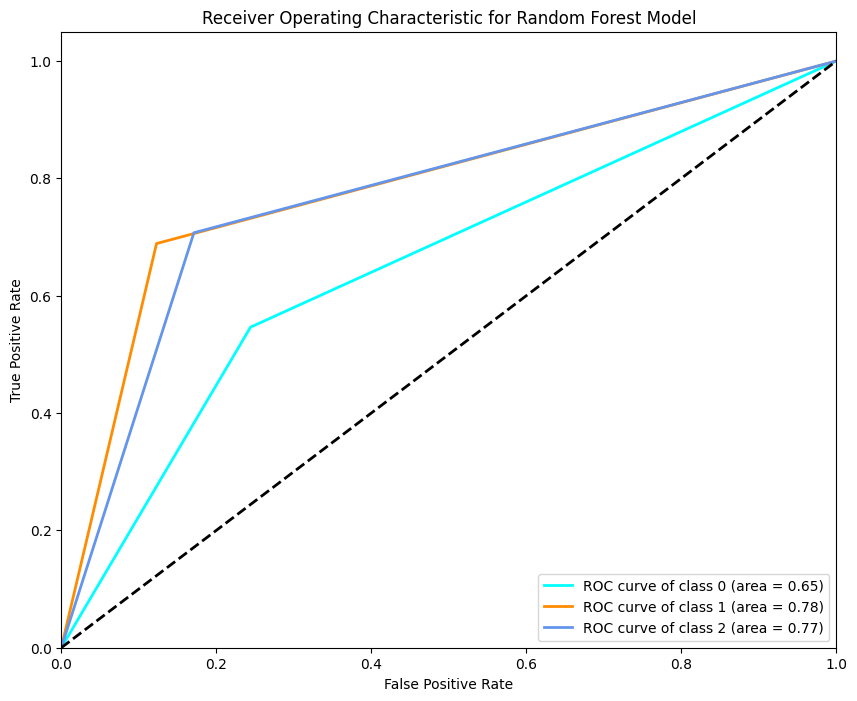

In [14]:
# Additional Graphs for Evaluation Metrics

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=loaded_rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=loaded_rf_model.classes_)

# Plot confusion matrix
plt.figure(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Random Forest Model')
plt.savefig('/content/drive/MyDrive/work2/Final/confusion_matrix.png')
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels for ROC curve
y_test_binarized = label_binarize(y_test, classes=loaded_rf_model.classes_)
y_pred_binarized = label_binarize(y_pred, classes=loaded_rf_model.classes_)
n_classes = y_test_binarized.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Random Forest Model')
plt.legend(loc="lower right")
plt.savefig('/content/drive/MyDrive/work2/Final/roc_curve.png')
plt.show()


Test accuracy: 64.31%
Precision: 0.64
Recall: 0.64
F1 Score: 0.64
Results saved to /content/drive/MyDrive/work2/Final/evaluation_results.csv


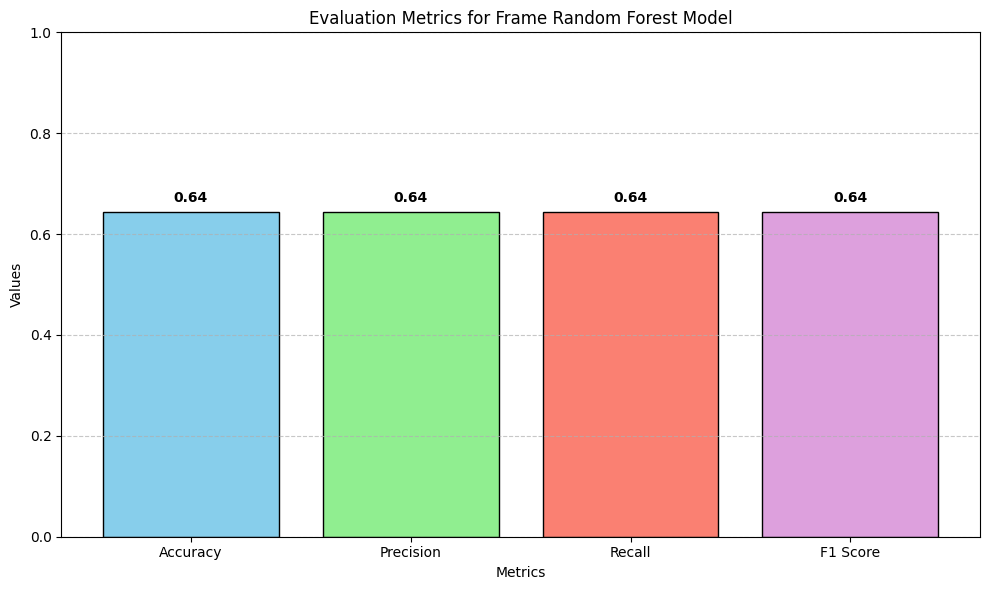

<Figure size 1000x1000 with 0 Axes>

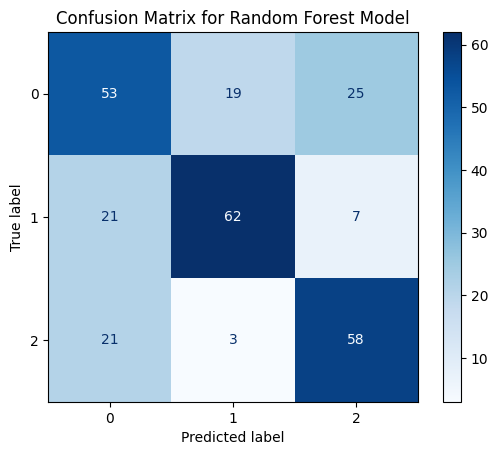

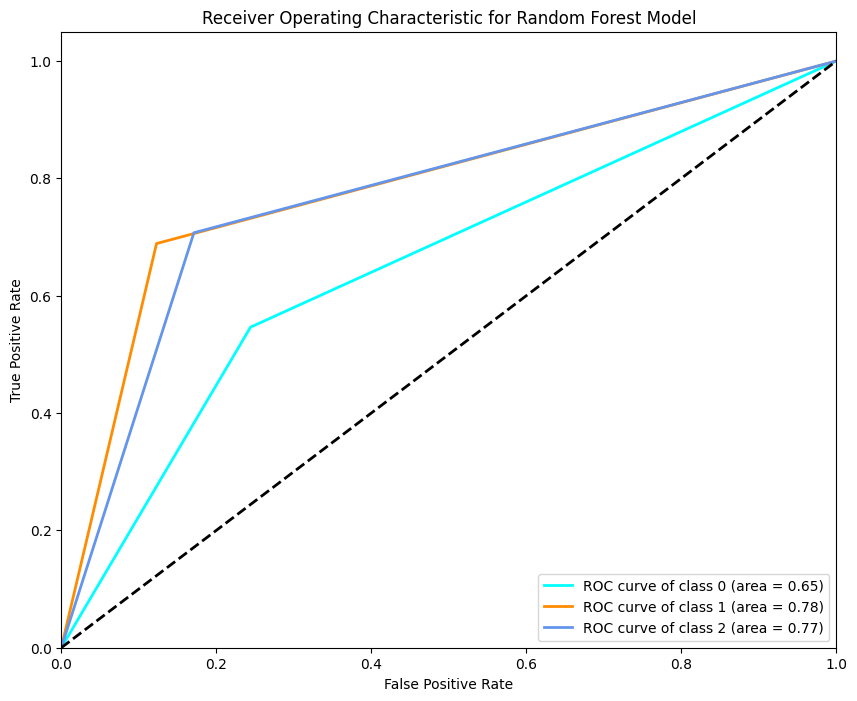

In [15]:
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from skimage.feature import hog
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/work2/Final/Final_Image_File/expanded_transcription_results_with_frames.csv')

# Function to preprocess images
def preprocess_image(filepath):
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
    img = cv2.imread(filepath)
    if img is None:
        print(f"Failed to read image: {filepath}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (128, 128))
    img = cv2.equalizeHist(img)
    return img

# Apply preprocessing to each image and prepare labels
images = []
labels = []
for idx, fp in enumerate(df['Frame Path']):
    processed_img = preprocess_image(fp)
    if processed_img is not None:
        images.append(processed_img)
        labels.append(df['Frame Senti'][idx])

images = np.array(images)
labels = np.array(labels)

# Extract HOG features from the images
hog_features = [hog(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys') for image in images]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(hog_features, labels, test_size=0.3, random_state=42)

# Load the saved model
joblib_file = "/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_2_random_forest_model.pkl"
loaded_rf_model = joblib.load(joblib_file)

# Evaluate the model
y_pred = loaded_rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f"Test accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['Random Forest'],
    'Model Path': [joblib_file],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Save the DataFrame to a CSV file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")

# Create directory if it does not exist
output_dir = '/content/drive/MyDrive/work2/Final'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Plot evaluation metrics bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(['Accuracy', 'Precision', 'Recall', 'F1 Score'], [accuracy, precision, recall, f1],
               color=['skyblue', 'lightgreen', 'salmon', 'plum'], edgecolor='black')
plt.ylim(0, 1)
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Evaluation Metrics for Frame Random Forest Model')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.2f}", ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'{output_dir}/evaluation_metrics_graph.png')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix for Random Forest Model')
plt.savefig(f'{output_dir}/confusion_matrix.png')
plt.show()

# ROC Curve
# Binarize the labels for ROC curve
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
y_pred_binarized = label_binarize(y_pred, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'ROC curve of class {i} (area = {roc_auc[i]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Random Forest Model')
plt.legend(loc="lower right")
plt.savefig(f'{output_dir}/roc_curve.png')
plt.show()



6/6 [==============================] - 12s 2s/step - loss: 1.0868 - accuracy: 0.6536
Test Loss: 1.0867706537246704, Test Accuracy: 0.6536312699317932
6/6 [==============================] - 10s 2s/step
Accuracy: 65.36%
Precision: 0.65
Recall: 0.65
F1 Score: 0.65
Results saved to /content/drive/MyDrive/work2/Final/evaluation_results.csv


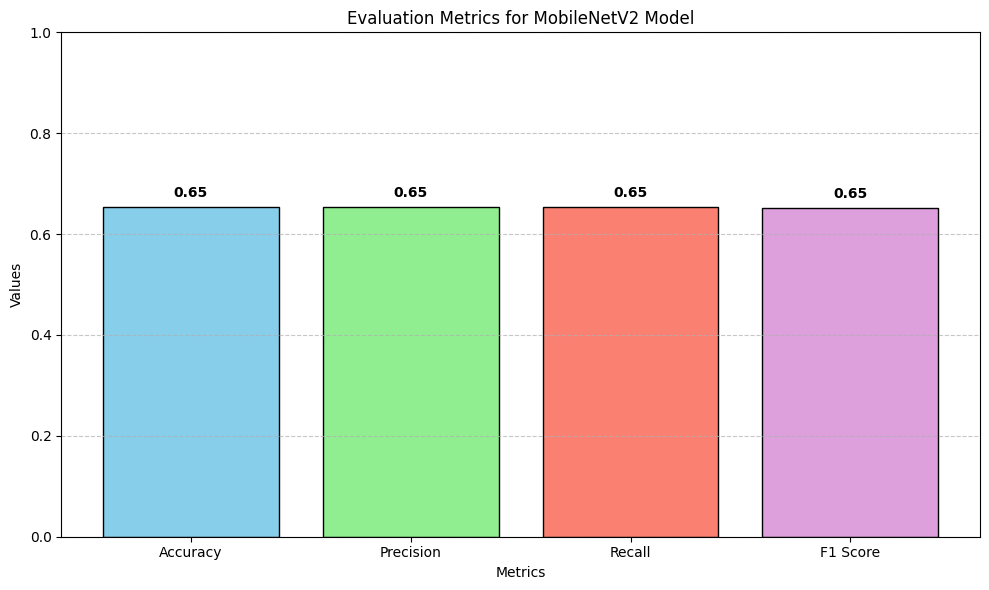

<Figure size 1000x1000 with 0 Axes>

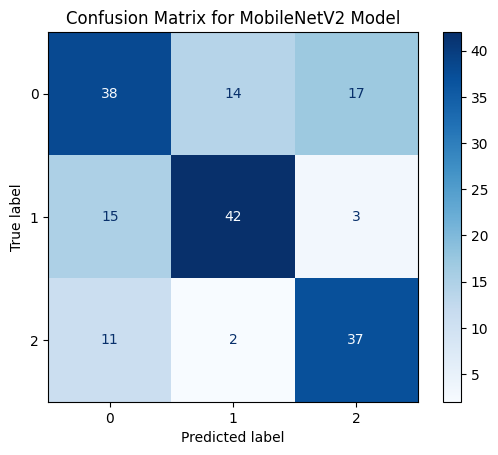

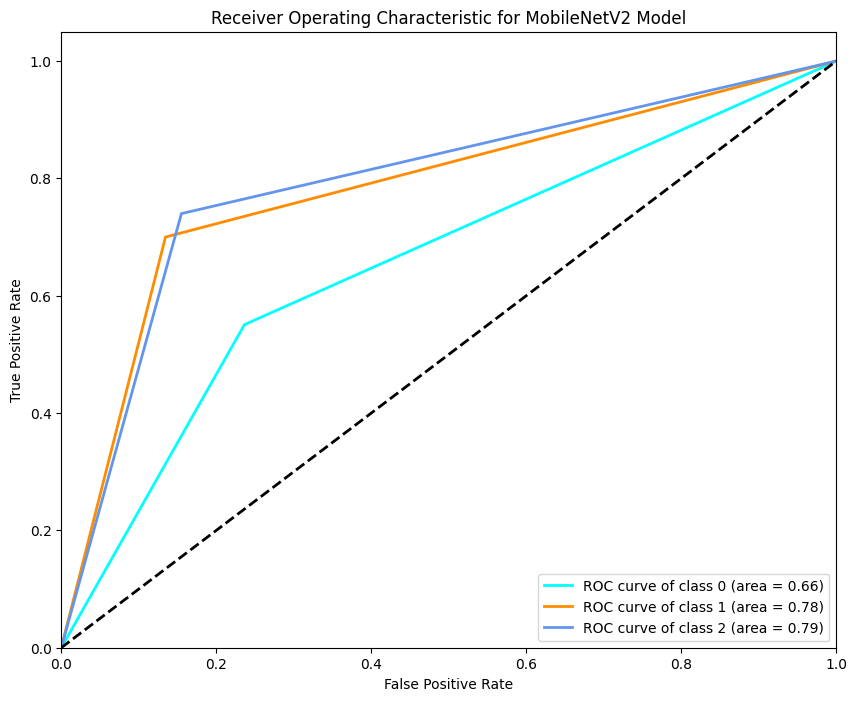

In [16]:
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import to_categorical
import os
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/work2/Final/Final_Image_File/expanded_transcription_results_with_frames.csv')

# Function to preprocess images
def preprocess_image(filepath):
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
    img = cv2.imread(filepath)
    if img is None:
        print(f"Failed to read image: {filepath}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))  # Resize to match MobileNetV2 input
    img = preprocess_input(img)  # Preprocess as per MobileNetV2 requirements
    return img

# Apply preprocessing to each image and prepare labels
images = []
labels = []
for idx, fp in enumerate(df['Frame Path']):
    processed_img = preprocess_image(fp)
    if processed_img is not None:
        images.append(processed_img)
        labels.append(df['Frame Senti'][idx])

images = np.array(images)
labels = np.array(labels)

# One-hot encode labels for categorical crossentropy
labels = to_categorical(labels, num_classes=3)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Load the saved TensorFlow model
model_path = '/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_1_CNN_with_MobileNetV2.h5'
loaded_model = tf.keras.models.load_model(model_path)

# Evaluate the loaded model
test_loss, test_accuracy = loaded_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

# Make predictions
y_pred_prob = loaded_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculate evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print evaluation metrics
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['MobileNetV2'],
    'Model Path': [model_path],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'

# Check if the results file exists
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

# Save the DataFrame to the CSV file
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")

# Create directory if it does not exist
output_dir = '/content/drive/MyDrive/work2/Final'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Plot evaluation metrics bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(['Accuracy', 'Precision', 'Recall', 'F1 Score'], [accuracy, precision, recall, f1],
               color=['skyblue', 'lightgreen', 'salmon', 'plum'], edgecolor='black')
plt.ylim(0, 1)
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Evaluation Metrics for MobileNetV2 Model')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.2f}", ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'{output_dir}/evaluation_metrics_graph_mobilenetv2.png')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix for MobileNetV2 Model')
plt.savefig(f'{output_dir}/confusion_matrix_mobilenetv2.png')
plt.show()

# ROC Curve
# Binarize the labels for ROC curve
y_test_binarized = label_binarize(y_true, classes=np.unique(y_true))
y_pred_binarized = label_binarize(y_pred, classes=np.unique(y_true))
n_classes = y_test_binarized.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'ROC curve of class {i} (area = {roc_auc[i]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for MobileNetV2 Model')
plt.legend(loc="lower right")
plt.savefig(f'{output_dir}/roc_curve_mobilenetv2.png')
plt.show()


9406464/9406464 [==============================] - 0s 0us/step
Epoch 1/10
23/23 [==============================] - 37s 1s/step - loss: 1.1594 - accuracy: 0.3729 - val_loss: 1.0565 - val_accuracy: 0.4693
Epoch 2/10
23/23 [==============================] - 34s 1s/step - loss: 1.0034 - accuracy: 0.4916 - val_loss: 1.0027 - val_accuracy: 0.4804
Epoch 3/10
23/23 [==============================] - 41s 2s/step - loss: 0.9355 - accuracy: 0.5223 - val_loss: 1.0035 - val_accuracy: 0.5698
Epoch 4/10
23/23 [==============================] - 37s 2s/step - loss: 0.9022 - accuracy: 0.5628 - val_loss: 1.0151 - val_accuracy: 0.5866
Epoch 5/10
23/23 [==============================] - 35s 2s/step - loss: 0.8741 - accuracy: 0.5838 - val_loss: 0.9613 - val_accuracy: 0.5922
Epoch 6/10
23/23 [==============================] - 38s 2s/step - loss: 0.8121 - accuracy: 0.6299 - val_loss: 0.9575 - val_accuracy: 0.5698
Epoch 7/10
23/23 [==============================] - 45s 2s/step - loss: 0.8056 - accuracy: 0.6369

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


6/6 [==============================] - 6s 985ms/step - loss: 0.9398 - accuracy: 0.5754
Test Loss: 0.9398314356803894, Test Accuracy: 0.575419008731842
6/6 [==============================] - 15s 2s/step
Accuracy: 57.54%
Precision: 0.60
Recall: 0.58
F1 Score: 0.57
Results saved to /content/drive/MyDrive/work2/Final/evaluation_results.csv


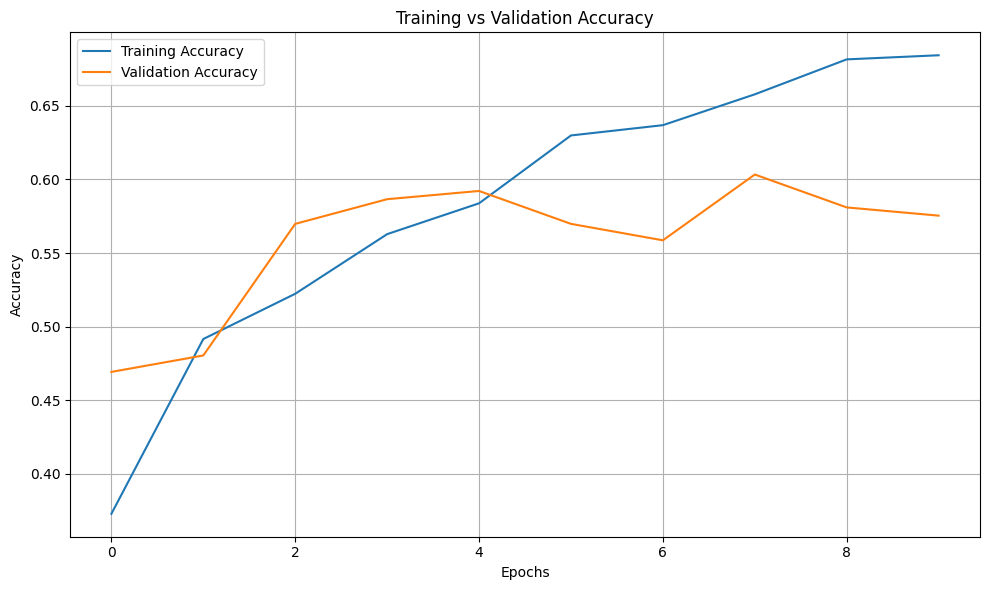

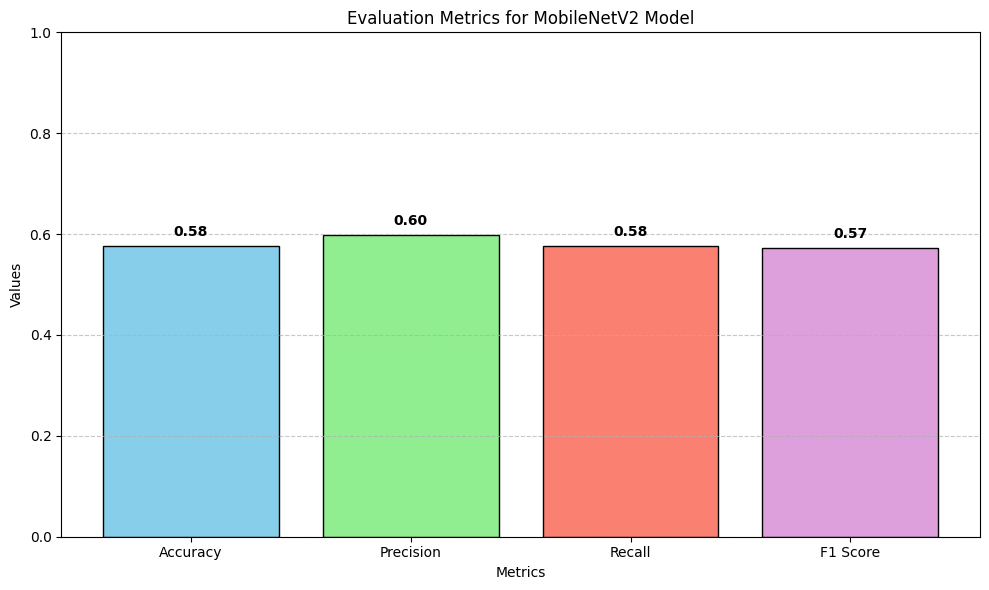

<Figure size 1000x1000 with 0 Axes>

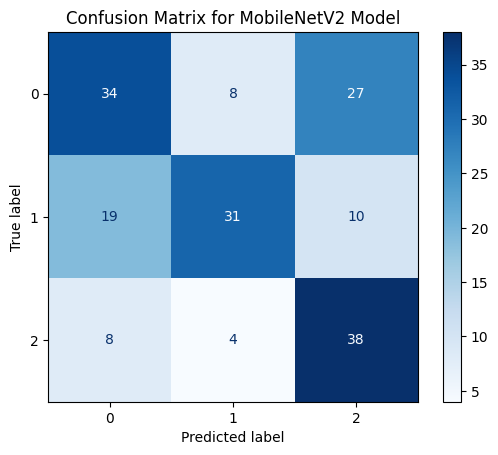

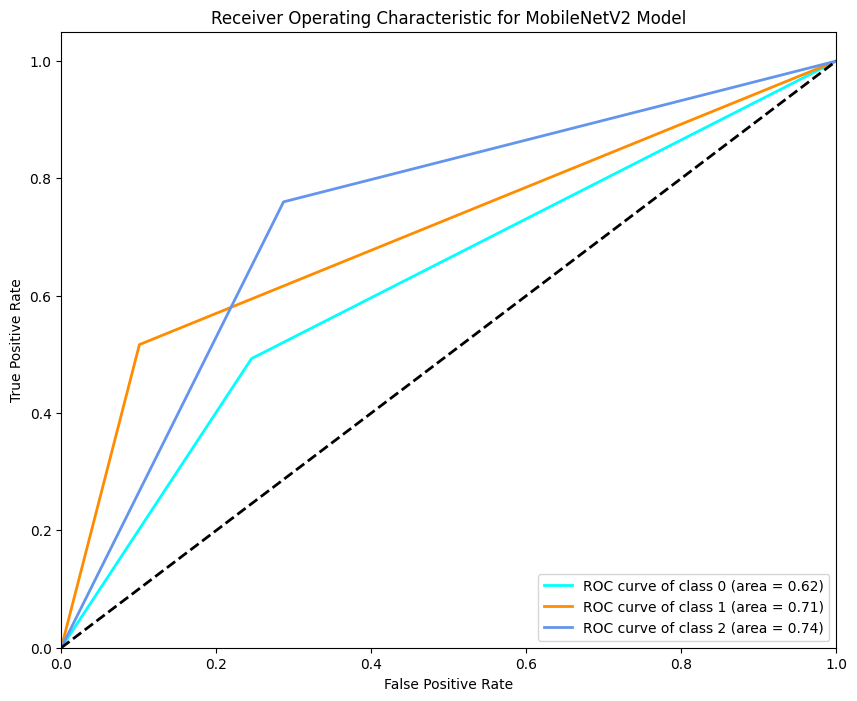

In [17]:
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import to_categorical
import os
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/work2/Final/Final_Image_File/expanded_transcription_results_with_frames.csv')

# Function to preprocess images
def preprocess_image(filepath):
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
    img = cv2.imread(filepath)
    if img is None:
        print(f"Failed to read image: {filepath}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))  # Resize to match MobileNetV2 input
    img = preprocess_input(img)  # Preprocess as per MobileNetV2 requirements
    return img

# Apply preprocessing to each image and prepare labels
images = []
labels = []
for idx, fp in enumerate(df['Frame Path']):
    processed_img = preprocess_image(fp)
    if processed_img is not None:
        images.append(processed_img)
        labels.append(df['Frame Senti'][idx])

images = np.array(images)
labels = np.array(labels)

# One-hot encode labels for categorical crossentropy
labels = to_categorical(labels, num_classes=3)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Define the model (Example MobileNetV2 model)
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model and save the history
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32)

# Save the model
model_path = '/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_1_CNN_with_MobileNetV2.h5'
model.save(model_path)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

# Make predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculate evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print evaluation metrics
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['MobileNetV2'],
    'Model Path': [model_path],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'

# Check if the results file exists
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

# Save the DataFrame to the CSV file
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")

# Create directory if it does not exist
output_dir = '/content/drive/MyDrive/work2/Final'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Plot training vs validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{output_dir}/training_vs_validation_accuracy.png')
plt.show()

# Plot evaluation metrics bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(['Accuracy', 'Precision', 'Recall', 'F1 Score'], [accuracy, precision, recall, f1],
               color=['skyblue', 'lightgreen', 'salmon', 'plum'], edgecolor='black')
plt.ylim(0, 1)
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Evaluation Metrics for MobileNetV2 Model')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.2f}", ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'{output_dir}/evaluation_metrics_graph_mobilenetv2.png')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix for MobileNetV2 Model')
plt.savefig(f'{output_dir}/confusion_matrix_mobilenetv2.png')
plt.show()

# ROC Curve
# Binarize the labels for ROC curve
y_test_binarized = label_binarize(y_true, classes=np.unique(y_true))
y_pred_binarized = label_binarize(y_pred, classes=np.unique(y_true))
n_classes = y_test_binarized.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'ROC curve of class {i} (area = {roc_auc[i]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for MobileNetV2 Model')
plt.legend(loc="lower right")
plt.savefig(f'{output_dir}/roc_curve_mobilenetv2.png')
plt.show()


Label distribution: {0: 17, 1: 54, 2: 40}
Epoch 1/100
2/2 [==============================] - 7s 3s/step - loss: 1.0973 - accuracy: 0.4286 - val_loss: 1.0871 - val_accuracy: 0.5000
Epoch 2/100


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


2/2 [==============================] - 1s 614ms/step - loss: 1.0849 - accuracy: 0.4805 - val_loss: 1.0770 - val_accuracy: 0.5000
Epoch 3/100
2/2 [==============================] - 1s 628ms/step - loss: 1.0717 - accuracy: 0.5325 - val_loss: 1.0641 - val_accuracy: 0.4706
Epoch 4/100
2/2 [==============================] - 1s 469ms/step - loss: 1.0627 - accuracy: 0.5325 - val_loss: 1.0482 - val_accuracy: 0.5000
Epoch 5/100
2/2 [==============================] - 1s 335ms/step - loss: 1.0341 - accuracy: 0.4935 - val_loss: 1.0282 - val_accuracy: 0.4706
Epoch 6/100
2/2 [==============================] - 1s 276ms/step - loss: 1.0118 - accuracy: 0.5195 - val_loss: 1.0719 - val_accuracy: 0.4706
Epoch 7/100
2/2 [==============================] - 1s 330ms/step - loss: 1.0156 - accuracy: 0.5325 - val_loss: 1.0586 - val_accuracy: 0.4706
Epoch 8/100
2/2 [==============================] - 1s 295ms/step - loss: 1.0113 - accuracy: 0.5455 - val_loss: 1.0051 - val_accuracy: 0.4706
Epoch 9/100
2/2 [========

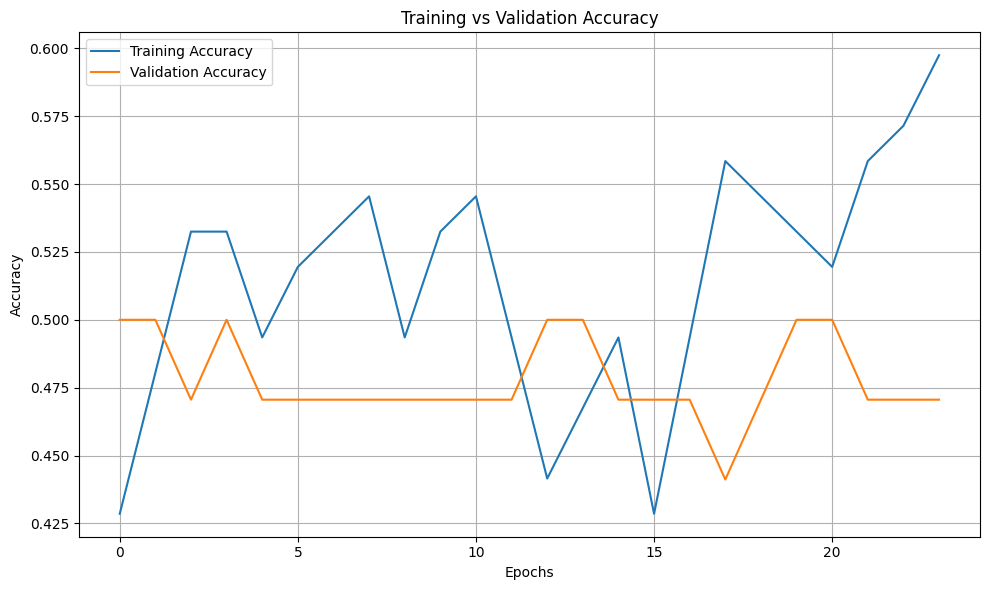

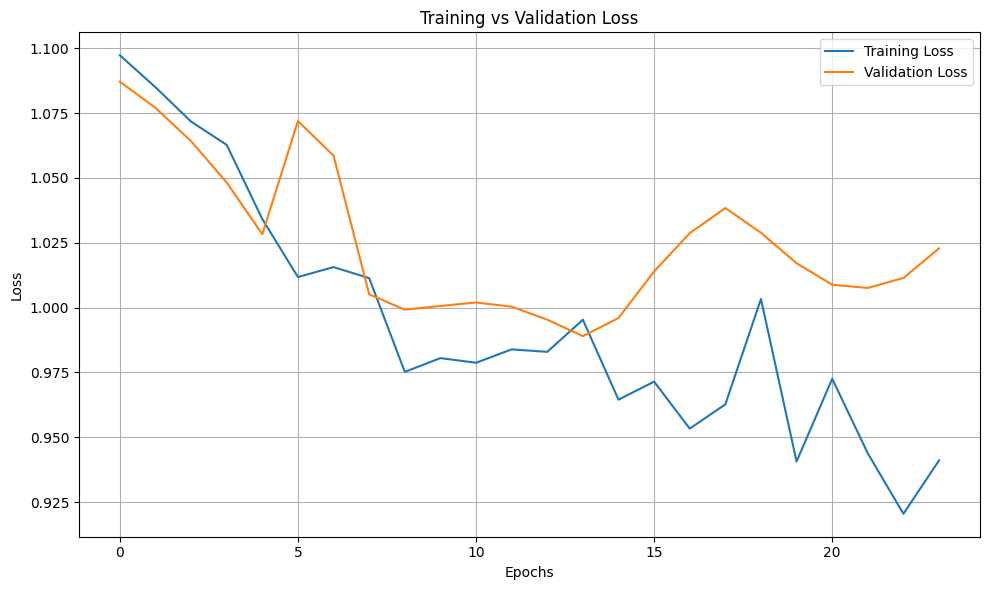

<Figure size 1000x1000 with 0 Axes>

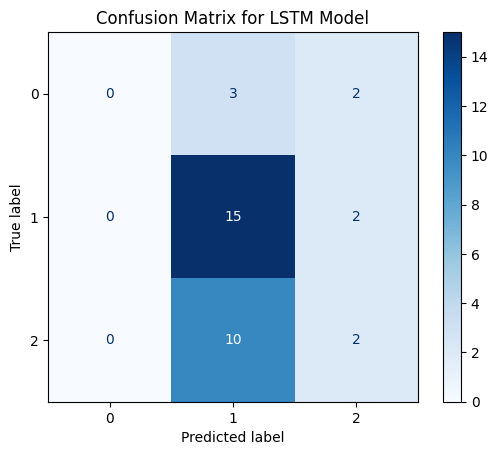

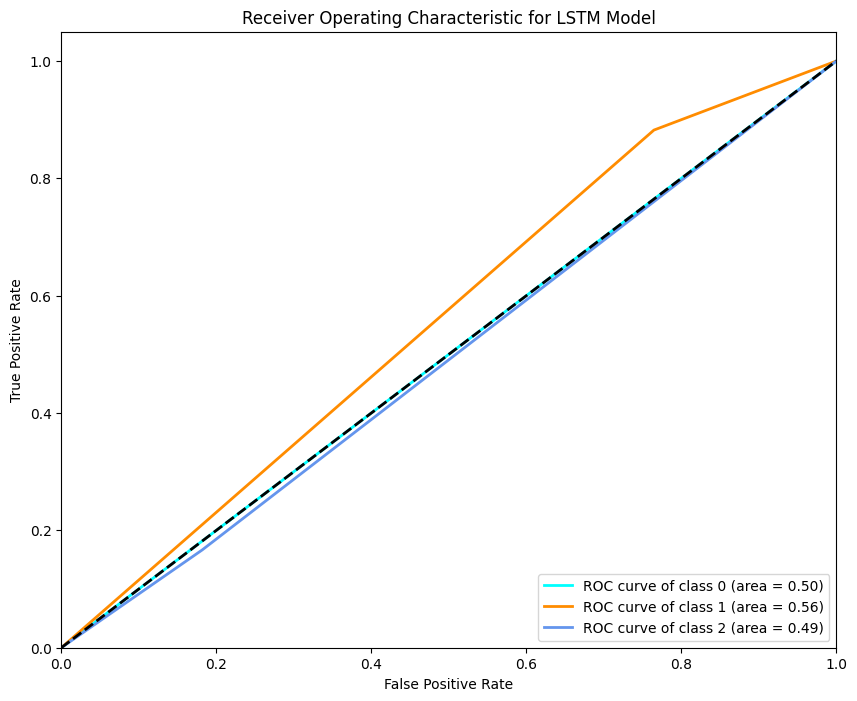

In [18]:
import librosa
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras import layers, models
import os
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Function to extract features from audio files
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    energy_contour = librosa.feature.rms(y=y)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

    features = np.concatenate((
        np.mean(mfccs, axis=1),
        np.mean(mel, axis=1),
        np.mean(contrast, axis=1),
        np.mean(bandwidth, axis=1),
        np.mean(energy_contour, axis=1),
        np.mean(spectral_rolloff, axis=1)
    ))
    return features

# Folder containing audio files
audio_folder = '/content/drive/MyDrive/work2_extra/wav'

# List to store audio file paths and sentiment labels
file_names = []
senti_values = []

# Iterate through files in the folder
for file_name in os.listdir(audio_folder):
    if os.path.isfile(os.path.join(audio_folder, file_name)):
        file_names.append(os.path.join(audio_folder, file_name))

# Load sentiment labels from a CSV file
csv_path = '/content/drive/MyDrive/work2/Meta_Data/Audio.csv'
df = pd.read_csv(csv_path)
senti_values = df['Senti'].tolist()

# Create a dataset (X, y) with features and labels
X = np.array([extract_features(path) for path in file_names])
y = np.array(senti_values)

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Check label distribution
unique, counts = np.unique(y, return_counts=True)
print("Label distribution:", dict(zip(unique, counts)))

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Save the scaler for later use
scaler_path = '/content/drive/MyDrive/work2/Final/Audio_Models/scaler_lstm.pkl'
joblib.dump(scaler, scaler_path)

# Reshape for LSTM input
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# Define early stopping and model checkpoint callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_1_LSTM.h5',
                             monitor='val_accuracy', save_best_only=True, mode='max')

# Build a neural network model with LSTM layers
model = models.Sequential()
model.add(layers.LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(layers.LSTM(64))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(len(np.unique(y)), activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model with callbacks
history = model.fit(X_train, y_train, epochs=100, batch_size=64,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping, checkpoint])

# Evaluate the best model on the test set
best_model = tf.keras.models.load_model('/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_1_LSTM.h5')
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

# Print evaluation metrics
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['LSTM'],
    'Model Path': ['/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_1_LSTM.h5'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'

# Check if the results file exists
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

# Save the DataFrame to the CSV file
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")

# Create directory if it does not exist
output_dir = '/content/drive/MyDrive/work2/Final'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Plot training vs validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{output_dir}/training_vs_validation_accuracy_lstm.png')
plt.show()

# Plot training vs validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{output_dir}/training_vs_validation_loss_lstm.png')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
plt.figure(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix for LSTM Model')
plt.savefig(f'{output_dir}/confusion_matrix_lstm.png')
plt.show()

# ROC Curve
# Binarize the labels for ROC curve
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
y_pred_binarized = label_binarize(y_pred_classes, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'ROC curve of class {i} (area = {roc_auc[i]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for LSTM Model')
plt.legend(loc="lower right")
plt.savefig(f'{output_dir}/roc_curve_lstm.png')
plt.show()


Label distribution: {0: 17, 1: 54, 2: 40}
Epoch 1/100
2/2 [==============================] - 13s 2s/step - loss: 1.0996 - accuracy: 0.3377 - val_loss: 1.0861 - val_accuracy: 0.4706
Epoch 2/100


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning:

You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.



2/2 [==============================] - 1s 399ms/step - loss: 1.0826 - accuracy: 0.5195 - val_loss: 1.0744 - val_accuracy: 0.5000
Epoch 3/100
2/2 [==============================] - 1s 332ms/step - loss: 1.0742 - accuracy: 0.4805 - val_loss: 1.0573 - val_accuracy: 0.5000
Epoch 4/100
2/2 [==============================] - 1s 409ms/step - loss: 1.0592 - accuracy: 0.4935 - val_loss: 1.0329 - val_accuracy: 0.5294
Epoch 5/100
2/2 [==============================] - 1s 334ms/step - loss: 1.0181 - accuracy: 0.5455 - val_loss: 1.0058 - val_accuracy: 0.5294
Epoch 6/100
2/2 [==============================] - 1s 325ms/step - loss: 0.9859 - accuracy: 0.5195 - val_loss: 1.0409 - val_accuracy: 0.4706
Epoch 7/100
2/2 [==============================] - 1s 335ms/step - loss: 0.9970 - accuracy: 0.4935 - val_loss: 1.0313 - val_accuracy: 0.4706
Epoch 8/100
2/2 [==============================] - 1s 338ms/step - loss: 0.9838 - accuracy: 0.5455 - val_loss: 0.9979 - val_accuracy: 0.5000
Epoch 9/100
2/2 [========

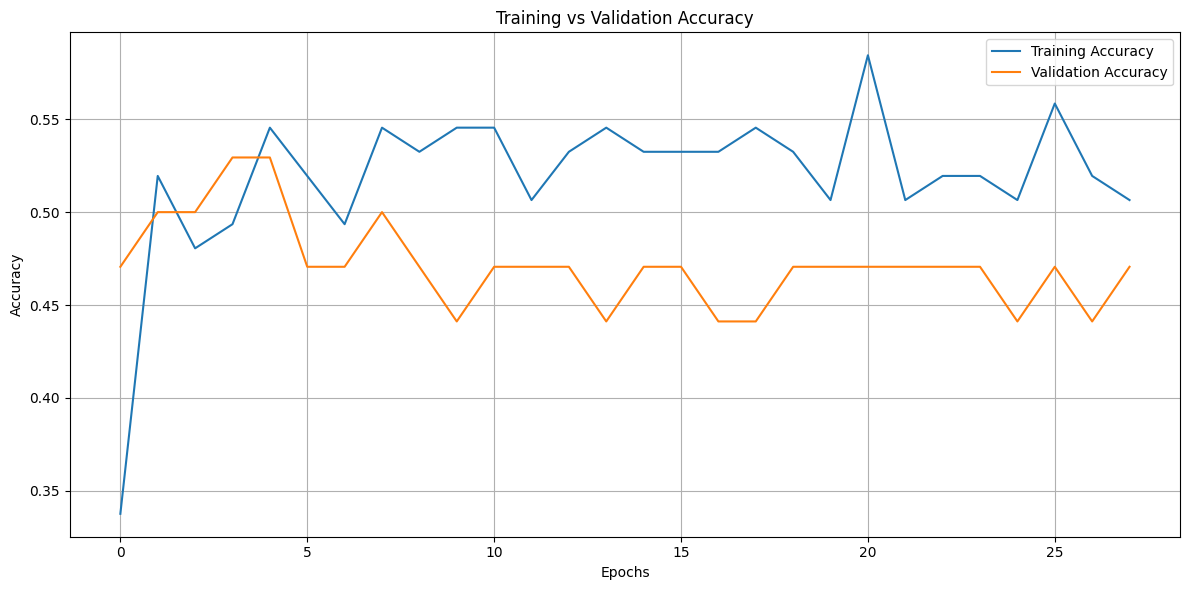

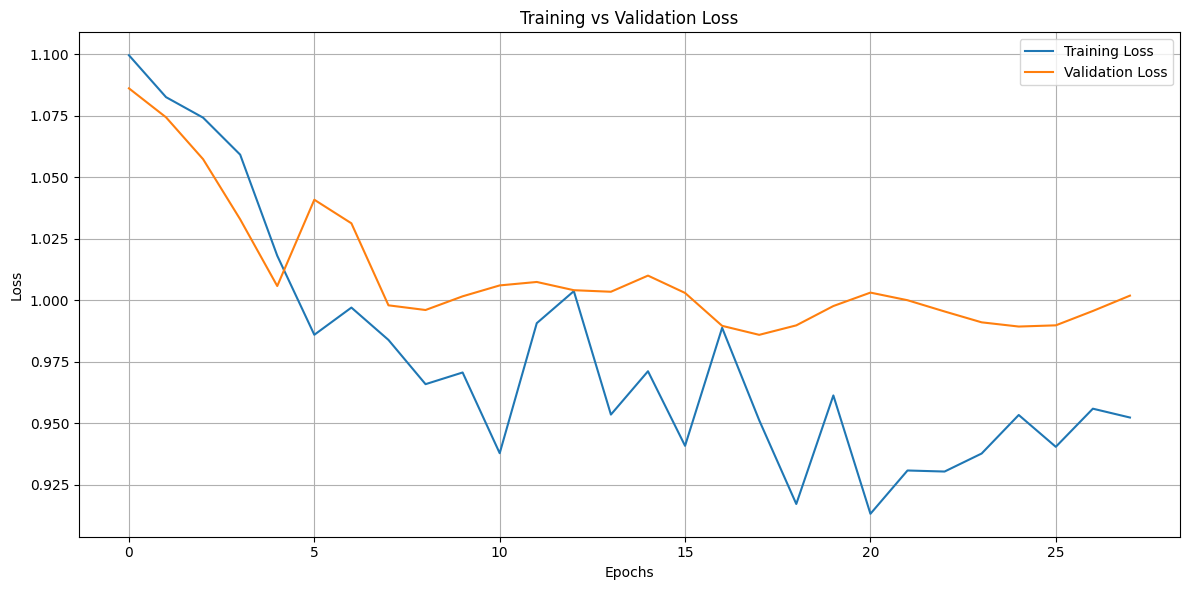

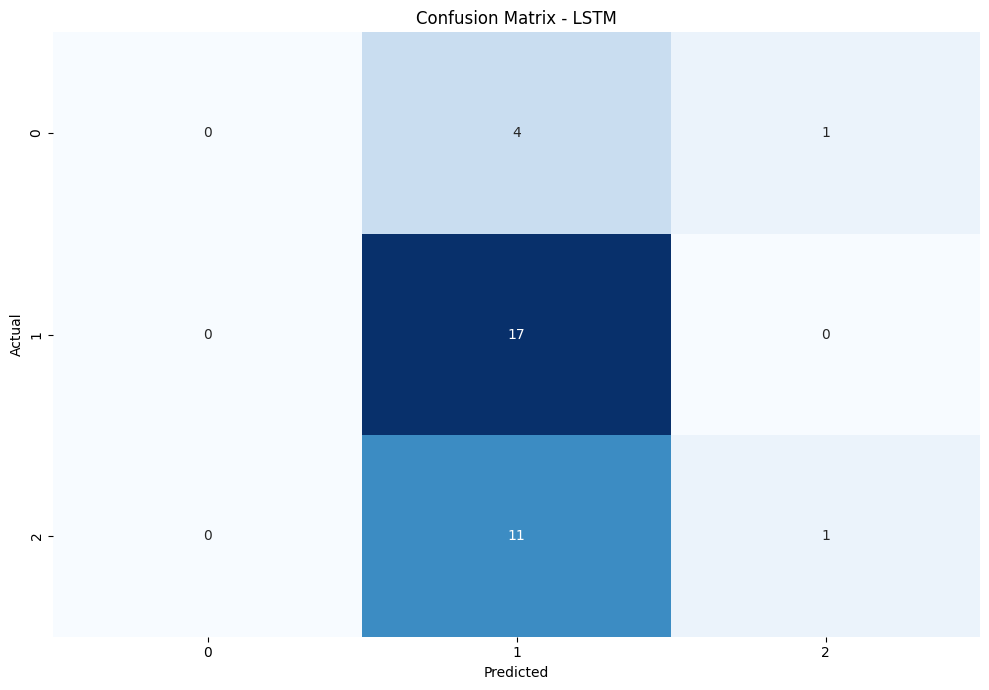

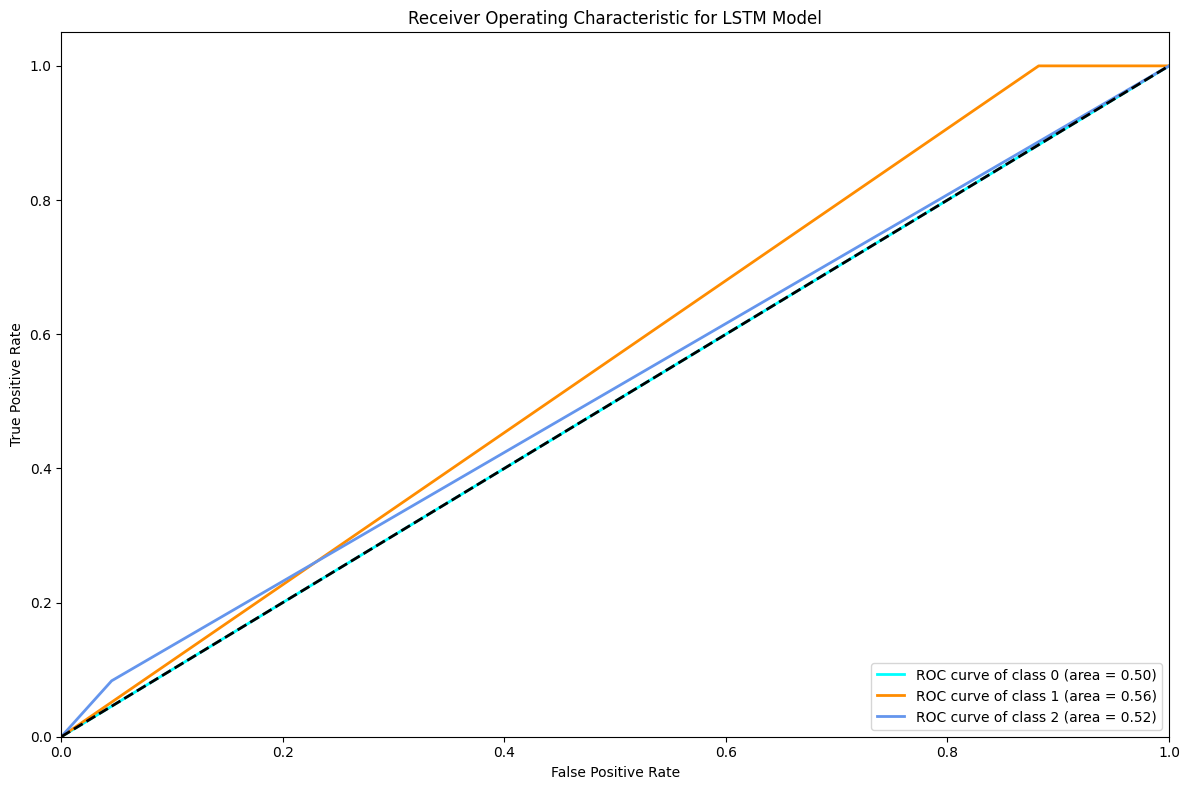

Results saved to /content/drive/MyDrive/work2/Final/evaluation_results.csv


In [24]:
import librosa
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras import layers, models
import os
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

# Function to extract features from audio files
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    energy_contour = librosa.feature.rms(y=y)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

    features = np.concatenate((
        np.mean(mfccs, axis=1),
        np.mean(mel, axis=1),
        np.mean(contrast, axis=1),
        np.mean(bandwidth, axis=1),
        np.mean(energy_contour, axis=1),
        np.mean(spectral_rolloff, axis=1)
    ))
    return features

# Folder containing audio files
audio_folder = '/content/drive/MyDrive/work2_extra/wav'

# List to store audio file paths and sentiment labels
file_names = []
senti_values = []

# Iterate through files in the folder
for file_name in os.listdir(audio_folder):
    if os.path.isfile(os.path.join(audio_folder, file_name)):
        file_names.append(os.path.join(audio_folder, file_name))

# Load sentiment labels from a CSV file
csv_path = '/content/drive/MyDrive/work2/Meta_Data/Audio.csv'
df = pd.read_csv(csv_path)
senti_values = df['Senti'].tolist()

# Create a dataset (X, y) with features and labels
X = np.array([extract_features(path) for path in file_names])
y = np.array(senti_values)

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Check label distribution
unique, counts = np.unique(y, return_counts=True)
print("Label distribution:", dict(zip(unique, counts)))

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Save the scaler for later use
scaler_path = '/content/drive/MyDrive/work2/Final/Audio_Models/scaler_lstm.pkl'
joblib.dump(scaler, scaler_path)

# Reshape for LSTM input
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# Define early stopping and model checkpoint callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_1_LSTM.h5',
                             monitor='val_accuracy', save_best_only=True, mode='max')

# Build a neural network model with LSTM layers
model = models.Sequential()
model.add(layers.LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(layers.LSTM(64))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(len(np.unique(y)), activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model with callbacks
history = model.fit(X_train, y_train, epochs=100, batch_size=64,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping, checkpoint])

# Evaluate the best model on the test set
best_model = tf.keras.models.load_model('/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_1_LSTM.h5')
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

# Print evaluation metrics
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Plot training vs validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/work2/Final/Audio_Models/training_vs_validation_accuracy.png')
plt.show()

# Plot training vs validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/work2/Final/Audio_Models/training_vs_validation_loss.png')
plt.show()

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Visualize the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/work2/Final/Audio_Models/confusion_matrix.png')
plt.show()

# ROC Curve
# Binarize the labels for ROC curve
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
y_pred_binarized = label_binarize(y_pred_classes, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(12, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'ROC curve of class {i} (area = {roc_auc[i]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for LSTM Model')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/work2/Final/Audio_Models/roc_curve.png')
plt.show()

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['LSTM'],
    'Model Path': ['/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_1_LSTM.h5'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'

# Check if the results file exists
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    updated_df = pd.concat([existing_df, results_df], ignore_index=True)
    updated_df.to_csv(results_file, index=False)
else:
    results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy: 52.17%
Precision: 0.56
Recall: 0.52
F1 Score: 0.45
Results saved to /content/drive/MyDrive/work2/Final/evaluation_results.csv


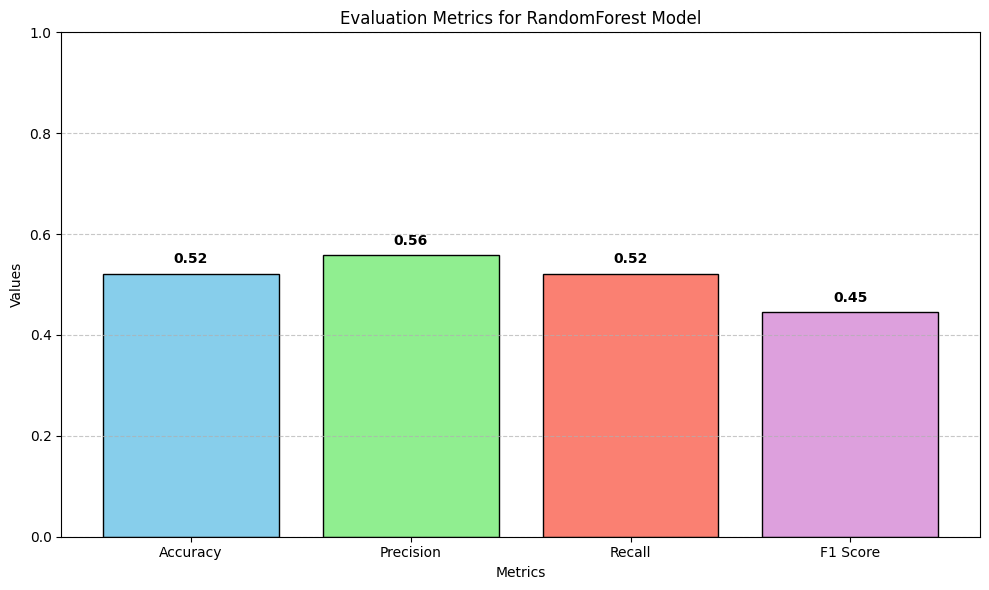

<Figure size 1000x1000 with 0 Axes>

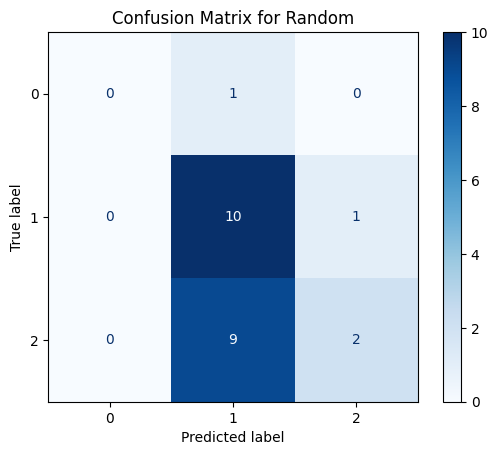

In [20]:
import librosa
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize
import joblib
import matplotlib.pyplot as plt

# Function to extract audio features
def extract_features(file_path):
    y, sr = librosa.load(file_path)
    mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)
    mel = np.mean(librosa.feature.melspectrogram(y=y, sr=sr), axis=1)
    spectral_contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr), axis=1)
    tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr), axis=1)
    return np.concatenate((mfccs, chroma, mel, spectral_contrast, tonnetz))

# Folder containing audio files
audio_folder = '/content/drive/MyDrive/work2_extra/wav'

# List to store audio file paths and sentiment labels
file_paths = []
sentiments = []

# Iterate through files in the folder and extract sentiment labels
for file_name in os.listdir(audio_folder):
    if os.path.isfile(os.path.join(audio_folder, file_name)):
        file_paths.append(os.path.join(audio_folder, file_name))

# Read sentiment labels from a CSV file
csv_path = '/content/drive/MyDrive/work2/Meta_Data/Audio.csv'
df = pd.read_csv(csv_path)
sentiments = df['Senti'].tolist()

# Create a dataset (X, y) with features and labels
X = [extract_features(path) for path in file_paths]
y = sentiments

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load the scaler
scaler_path = '/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_2_RandomForest_Scaler.joblib'
scaler = joblib.load(scaler_path)

# Standardize the features
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the saved model
model_path = '/content/drive/MyDrive/work2/Final/Audio_Models/Audio_Model_2_RandomForest.joblib'
loaded_model = joblib.load(model_path)

# Evaluate the loaded model
y_pred = loaded_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['Audio Sentiment RF'],
    'Model Path': [model_path],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'

# Check if the results file exists
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

# Save the DataFrame to the CSV file
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")

# Create directory if it does not exist
output_dir = '/content/drive/MyDrive/work2/Final'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Plot evaluation metrics bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(['Accuracy', 'Precision', 'Recall', 'F1 Score'], [accuracy, precision, recall, f1],
               color=['skyblue', 'lightgreen', 'salmon', 'plum'], edgecolor='black')
plt.ylim(0, 1)
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Evaluation Metrics for RandomForest Model')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.2f}", ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'{output_dir}/evaluation_metrics_graph_rf.png')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
plt.figure(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix for Random')
plt.savefig(f'{output_dir}/confusion_matrix_rf.png')
plt.show()


In [21]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset, random_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import os

# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/work2/Final/Text_Work/Files/sentences.csv", encoding='utf-8')
df1 = pd.read_csv("/content/drive/MyDrive/work2/Final/Text_Work/Files/updated_transcriptions_with_senti (1).csv", encoding='utf-8')

# Tokenize the reviews using BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize and encode the reviews
input_ids = []
attention_masks = []

for review in df['Sentence']:
    encoded_dict = tokenizer.encode_plus(
        review,
        add_special_tokens=True,
        max_length=64,
        truncation=True,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)

# Do the same for df1
input_ids1 = []
attention_masks1 = []

for review in df1['Sentence']:
    encoded_dict = tokenizer.encode_plus(
        review,
        add_special_tokens=True,
        max_length=64,
        truncation=True,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids1.append(encoded_dict['input_ids'])
    attention_masks1.append(encoded_dict['attention_mask'])

input_ids1 = torch.cat(input_ids1, dim=0)
attention_masks1 = torch.cat(attention_masks1, dim=0)

# Load the labels
labels = torch.tensor(df['Label'])
labels1 = torch.tensor(df1['Label'])

# Concatenate inputs and labels
input_ids = torch.cat((input_ids, input_ids1), dim=0)
attention_masks = torch.cat((attention_masks, attention_masks1), dim=0)
labels = torch.cat((labels, labels1), dim=0)

# Split the dataset into training and validation sets
dataset = TensorDataset(input_ids, attention_masks, labels)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load pre-trained BERT model for sentiment classification
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    output_attentions=False,
    output_hidden_states=False
)

# Set up optimizer and learning rate scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, eps=1e-8)

# Evaluation loop
model.eval()
all_labels = []
all_preds = []

for batch in val_dataloader:
    inputs = {
        'input_ids': batch[0],
        'attention_mask': batch[1],
        'labels': batch[2]
    }
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    preds = np.argmax(logits.cpu().numpy(), axis=1)

    all_labels.extend(inputs['labels'].cpu().numpy())
    all_preds.extend(preds)

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Generate confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(conf_matrix)

# Print classification report
class_report = classification_report(all_labels, all_preds, target_names=['neutral', 'positive', 'negative'])
print('Classification Report:')
print(class_report)

# Visualize the results
# Calculate precision, recall, and F1-score
class_report_dict = classification_report(all_labels, all_preds, target_names=['neutral', 'positive', 'negative'], output_dict=True)
precision = [class_report_dict[label]['precision'] for label in ['neutral', 'positive', 'negative']]
recall = [class_report_dict[label]['recall'] for label in ['neutral', 'positive', 'negative']]
f1_score = [class_report_dict[label]['f1-score'] for label in ['neutral', 'positive', 'negative']]

# Create an interactive confusion matrix
fig = make_subplots(rows=2, cols=2, subplot_titles=['Confusion Matrix', 'Accuracy Bar Chart', 'Precision Bar Chart', 'Recall Bar Chart'])

# Confusion Matrix
trace_heatmap = go.Heatmap(z=conf_matrix, x=['neutral', 'positive', 'negative'], y=['neutral', 'positive', 'negative'], colorscale='Viridis')
fig.add_trace(trace_heatmap, row=1, col=1)

# Accuracy Bar Chart
trace_bar_accuracy = go.Bar(x=['Accuracy'], y=[accuracy * 100], marker=dict(color='blue'))
fig.add_trace(trace_bar_accuracy, row=1, col=2)

# Precision Bar Chart
trace_bar_precision = go.Bar(x=['neutral', 'positive', 'negative'], y=np.round(precision, 2) * 100, marker=dict(color='green'))
fig.add_trace(trace_bar_precision, row=2, col=1)

# Recall Bar Chart
trace_bar_recall = go.Bar(x=['neutral', 'positive', 'negative'], y=np.round(recall, 2) * 100, marker=dict(color='orange'))
fig.add_trace(trace_bar_recall, row=2, col=2)

fig.update_layout(title_text='Confusion Matrix, Accuracy, Precision, and Recall', height=600, width=800)
fig.show()

# Save the results to a CSV file
results_df = pd.DataFrame({
    'Model Name': ['BERT Multilingual'],
    'Model Path': ['bert-base-uncased'],
    'Accuracy': [accuracy],
    'Precision': [np.mean(precision)],
    'Recall': [np.mean(recall)],
    'F1 Score': [np.mean(f1_score)]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'

# Check if the results file exists
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

# Save the DataFrame to the CSV file
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Accuracy: 22.97%
Confusion Matrix:
[[51 11  0]
 [78  0  0]
 [82  0  0]]
Classification Report:
              precision    recall  f1-score   support

     neutral       0.24      0.82      0.37        62
    positive       0.00      0.00      0.00        78
    negative       0.00      0.00      0.00        82

    accuracy                           0.23       222
   macro avg       0.08      0.27      0.12       222
weighted avg       0.07      0.23      0.10       222



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif

Results saved to /content/drive/MyDrive/work2/Final/evaluation_results.csv


In [22]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset, random_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import os
from sklearn.preprocessing import label_binarize

# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/work2/Final/Text_Work/Files/sentences.csv", encoding='utf-8')
df1 = pd.read_csv("/content/drive/MyDrive/work2/Final/Text_Work/Files/updated_transcriptions_with_senti (1).csv", encoding='utf-8')

# Tokenize the reviews using BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize and encode the reviews
input_ids = []
attention_masks = []

for review in df['Sentence']:
    encoded_dict = tokenizer.encode_plus(
        review,
        add_special_tokens=True,
        max_length=64,
        truncation=True,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)

# Do the same for df1
input_ids1 = []
attention_masks1 = []

for review in df1['Sentence']:
    encoded_dict = tokenizer.encode_plus(
        review,
        add_special_tokens=True,
        max_length=64,
        truncation=True,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids1.append(encoded_dict['input_ids'])
    attention_masks1.append(encoded_dict['attention_mask'])

input_ids1 = torch.cat(input_ids1, dim=0)
attention_masks1 = torch.cat(attention_masks1, dim=0)

# Load the labels
labels = torch.tensor(df['Label'])
labels1 = torch.tensor(df1['Label'])

# Concatenate inputs and labels
input_ids = torch.cat((input_ids, input_ids1), dim=0)
attention_masks = torch.cat((attention_masks, attention_masks1), dim=0)
labels = torch.cat((labels, labels1), dim=0)

# Split the dataset into training and validation sets
dataset = TensorDataset(input_ids, attention_masks, labels)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load pre-trained BERT model for sentiment classification
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    output_attentions=False,
    output_hidden_states=False
)

# Set up optimizer and learning rate scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, eps=1e-8)

# Evaluation loop
model.eval()
all_labels = []
all_preds = []
all_probs = []

for batch in val_dataloader:
    inputs = {
        'input_ids': batch[0],
        'attention_mask': batch[1],
        'labels': batch[2]
    }
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    preds = np.argmax(logits.cpu().numpy(), axis=1)
    probs = torch.nn.functional.softmax(logits, dim=1).cpu().numpy()

    all_labels.extend(inputs['labels'].cpu().numpy())
    all_preds.extend(preds)
    all_probs.extend(probs)

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Generate confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(conf_matrix)

# Print classification report
class_report = classification_report(all_labels, all_preds, target_names=['neutral', 'positive', 'negative'])
print('Classification Report:')
print(class_report)

# Visualize the results
# Calculate precision, recall, and F1-score
class_report_dict = classification_report(all_labels, all_preds, target_names=['neutral', 'positive', 'negative'], output_dict=True)
precision = [class_report_dict[label]['precision'] for label in ['neutral', 'positive', 'negative']]
recall = [class_report_dict[label]['recall'] for label in ['neutral', 'positive', 'negative']]
f1_score = [class_report_dict[label]['f1-score'] for label in ['neutral', 'positive', 'negative']]

# Create an interactive confusion matrix
fig = make_subplots(rows=2, cols=2, subplot_titles=['Confusion Matrix', 'Accuracy Bar Chart', 'Precision Bar Chart', 'Recall Bar Chart'])

# Confusion Matrix
trace_heatmap = go.Heatmap(z=conf_matrix, x=['neutral', 'positive', 'negative'], y=['neutral', 'positive', 'negative'], colorscale='Viridis')
fig.add_trace(trace_heatmap, row=1, col=1)

# Accuracy Bar Chart
trace_bar_accuracy = go.Bar(x=['Accuracy'], y=[accuracy * 100], marker=dict(color='blue'))
fig.add_trace(trace_bar_accuracy, row=1, col=2)

# Precision Bar Chart
trace_bar_precision = go.Bar(x=['neutral', 'positive', 'negative'], y=np.round(precision, 2) * 100, marker=dict(color='green'))
fig.add_trace(trace_bar_precision, row=2, col=1)

# Recall Bar Chart
trace_bar_recall = go.Bar(x=['neutral', 'positive', 'negative'], y=np.round(recall, 2) * 100, marker=dict(color='orange'))
fig.add_trace(trace_bar_recall, row=2, col=2)

fig.update_layout(title_text='Confusion Matrix, Accuracy, Precision, and Recall', height=600, width=800)
fig.show()

# Plot ROC curve for each class
all_labels_binarized = label_binarize(all_labels, classes=[0, 1, 2])
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(all_labels_binarized[:, i], np.array(all_probs)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fig_roc = go.Figure()

for i, color in zip(range(3), ['blue', 'green', 'red']):
    fig_roc.add_trace(go.Scatter(x=fpr[i], y=tpr[i], mode='lines', name=f'Class {i} (AUC = {roc_auc[i]:.2f})', line=dict(color=color)))

fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random', line=dict(color='black', dash='dash')))
fig_roc.update_layout(title='ROC Curve', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate', height=600, width=800)
fig_roc.show()

# Save the results to a CSV file
results_df = pd.DataFrame({
    'Model Name': ['BERT Multilingual'],
    'Model Path': ['bert-base-uncased'],
    'Accuracy': [accuracy],
    'Precision': [np.mean(precision)],
    'Recall': [np.mean(recall)],
    'F1 Score': [np.mean(f1_score)]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'

# Check if the results file exists
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

# Save the DataFrame to the CSV file
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Accuracy: 31.08%
Confusion Matrix:
[[69  0  0]
 [81  0  0]
 [72  0  0]]
Classification Report:
              precision    recall  f1-score   support

     neutral       0.31      1.00      0.47        69
    positive       0.00      0.00      0.00        81
    negative       0.00      0.00      0.00        72

    accuracy                           0.31       222
   macro avg       0.10      0.33      0.16       222
weighted avg       0.10      0.31      0.15       222



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` p

Results saved to /content/drive/MyDrive/work2/Final/evaluation_results.csv


Accuracy: 98.65%
Precision: 0.99
Recall: 0.99
F1 Score: 0.99
Confusion Matrix:
[[67  0  1]
 [ 0 65  0]
 [ 0  2 87]]


<ipython-input-23-f2549835635b>:80: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-23-f2549835635b>:88: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




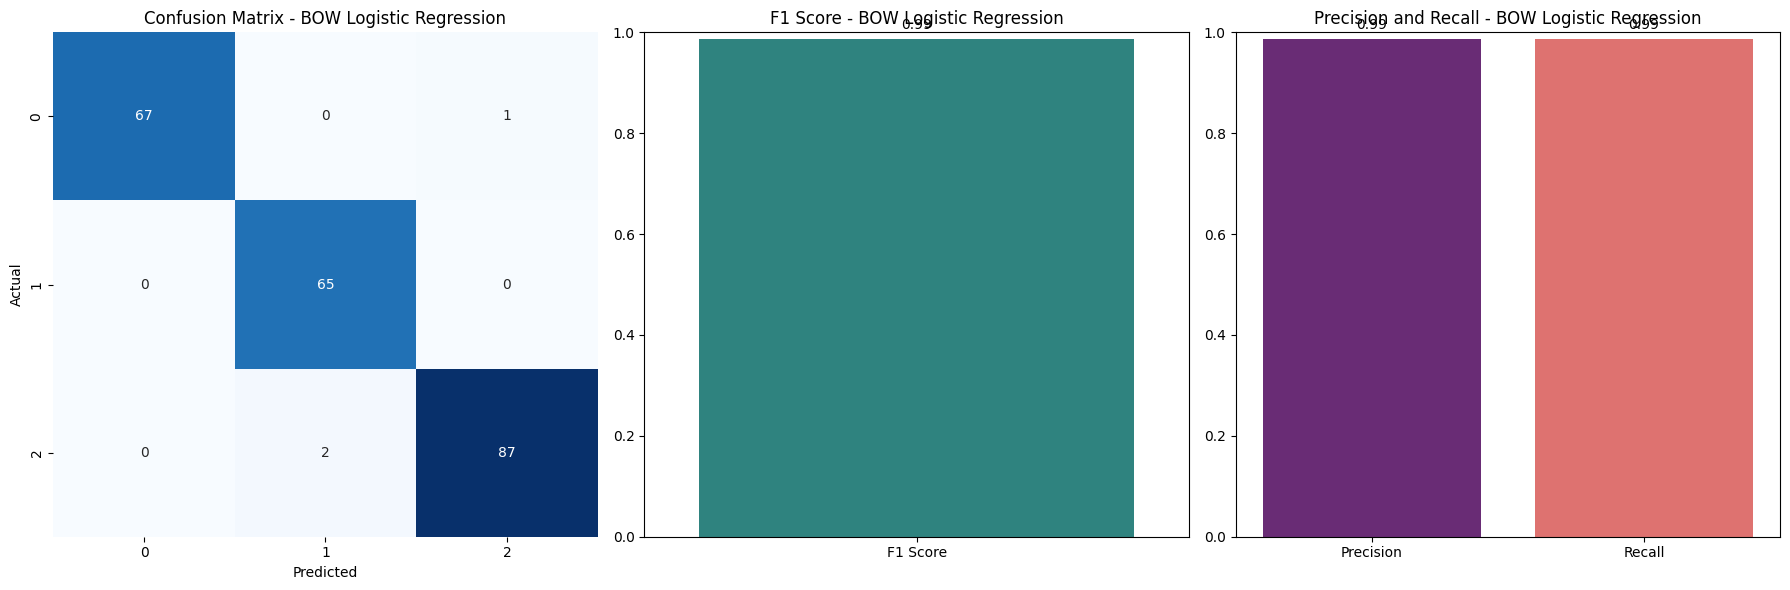

Results saved to /content/drive/MyDrive/work2/Final/evaluation_results.csv


In [23]:
import numpy as np
import pandas as pd
import re
import nltk
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split

# Load your dataset
df = pd.read_csv('/content/drive/MyDrive/work2/Final/Text_Work/Files/sentences.csv')
df1 = pd.read_csv('/content/drive/MyDrive/work2/Final/Text_Work/Files/updated_transcriptions_with_senti (1).csv')
urdu_doc = pd.concat([df, df1], ignore_index=True).dropna()

# Function to remove unwanted characters
def removing_unwanted_data(text):
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    text = re.sub(r'\<a href', ' ', text)
    text = re.sub(r'&amp;', '', text)
    text = re.sub(r'[_"\-;%()|+&=*%.,!?:#$@\[\]/]', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'\'', ' ', text)
    text = nltk.WordPunctTokenizer().tokenize(text)
    return text

# Apply preprocessing
urdu_doc['text_cleaned'] = urdu_doc['Sentence'].map(removing_unwanted_data)

# Custom tokenizer function
def custom_tokenizer(doc):
    return doc

# Load the saved vectorizer and model
vectorizer_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_bow_vectorizer.pkl'
model_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_logistic_regression_bow.pkl'

vectorizer = joblib.load(vectorizer_path)
model = joblib.load(model_path)

# Transform the data using the loaded vectorizer
X = vectorizer.transform(urdu_doc['text_cleaned'])
y = urdu_doc['Label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Evaluate the loaded model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

# Visualize the results
plt.figure(figsize=(18, 6))

# Confusion Matrix
plt.subplot(1, 3, 1)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - BOW Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# F1 Score
plt.subplot(1, 3, 2)
sns.barplot(x=['F1 Score'], y=[f1], palette="viridis")
plt.title("F1 Score - BOW Logistic Regression")
plt.ylim(0, 1)
for index, value in enumerate([f1]):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center')

# Precision and Recall
plt.subplot(1, 3, 3)
sns.barplot(x=['Precision', 'Recall'], y=[precision, recall], palette="magma")
plt.title("Precision and Recall - BOW Logistic Regression")
plt.ylim(0, 1)
for index, value in enumerate([precision, recall]):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center')

plt.tight_layout()
plt.show()

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['BOW Logistic Regression'],
    'Model Path': [model_path],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results.csv'

# Check if the results file exists and handle the append operation correctly
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    updated_df = pd.concat([existing_df, results_df], ignore_index=True)
    updated_df.to_csv(results_file, index=False)
else:
    results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 3843      
                                                                 
Total params: 2261827 (8.63 MB)
Trainable params: 3843 (15.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


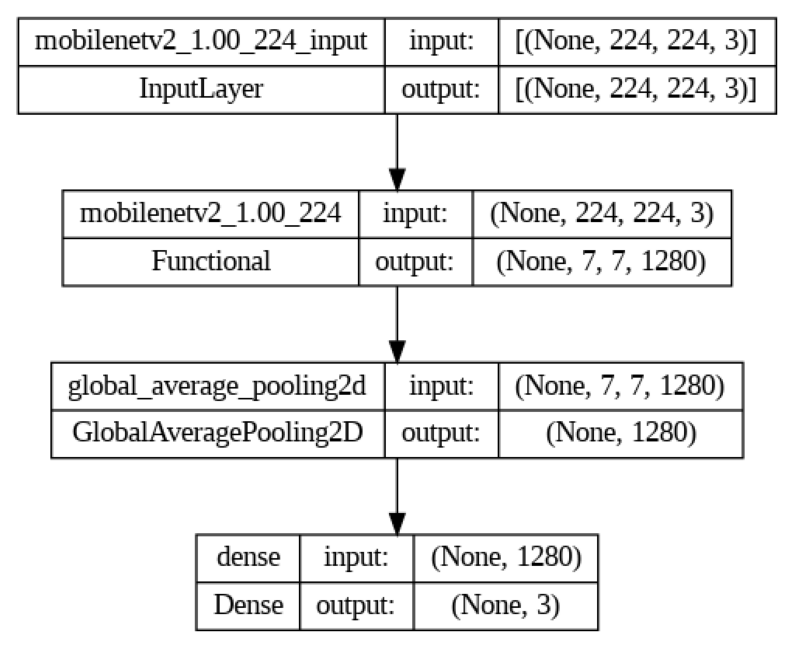

In [26]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load the model from the saved .h5 file
loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_1_CNN_with_MobileNetV2.h5')

# Display the model summary
loaded_model.summary()

# Plot the model architecture as a graph
tf.keras.utils.plot_model(loaded_model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

# Show the plot
img = plt.imread('model_architecture.png')
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()


Number of trees in the Random Forest: 500
Parameters of the Random Forest: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 500, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Number of features: 8100


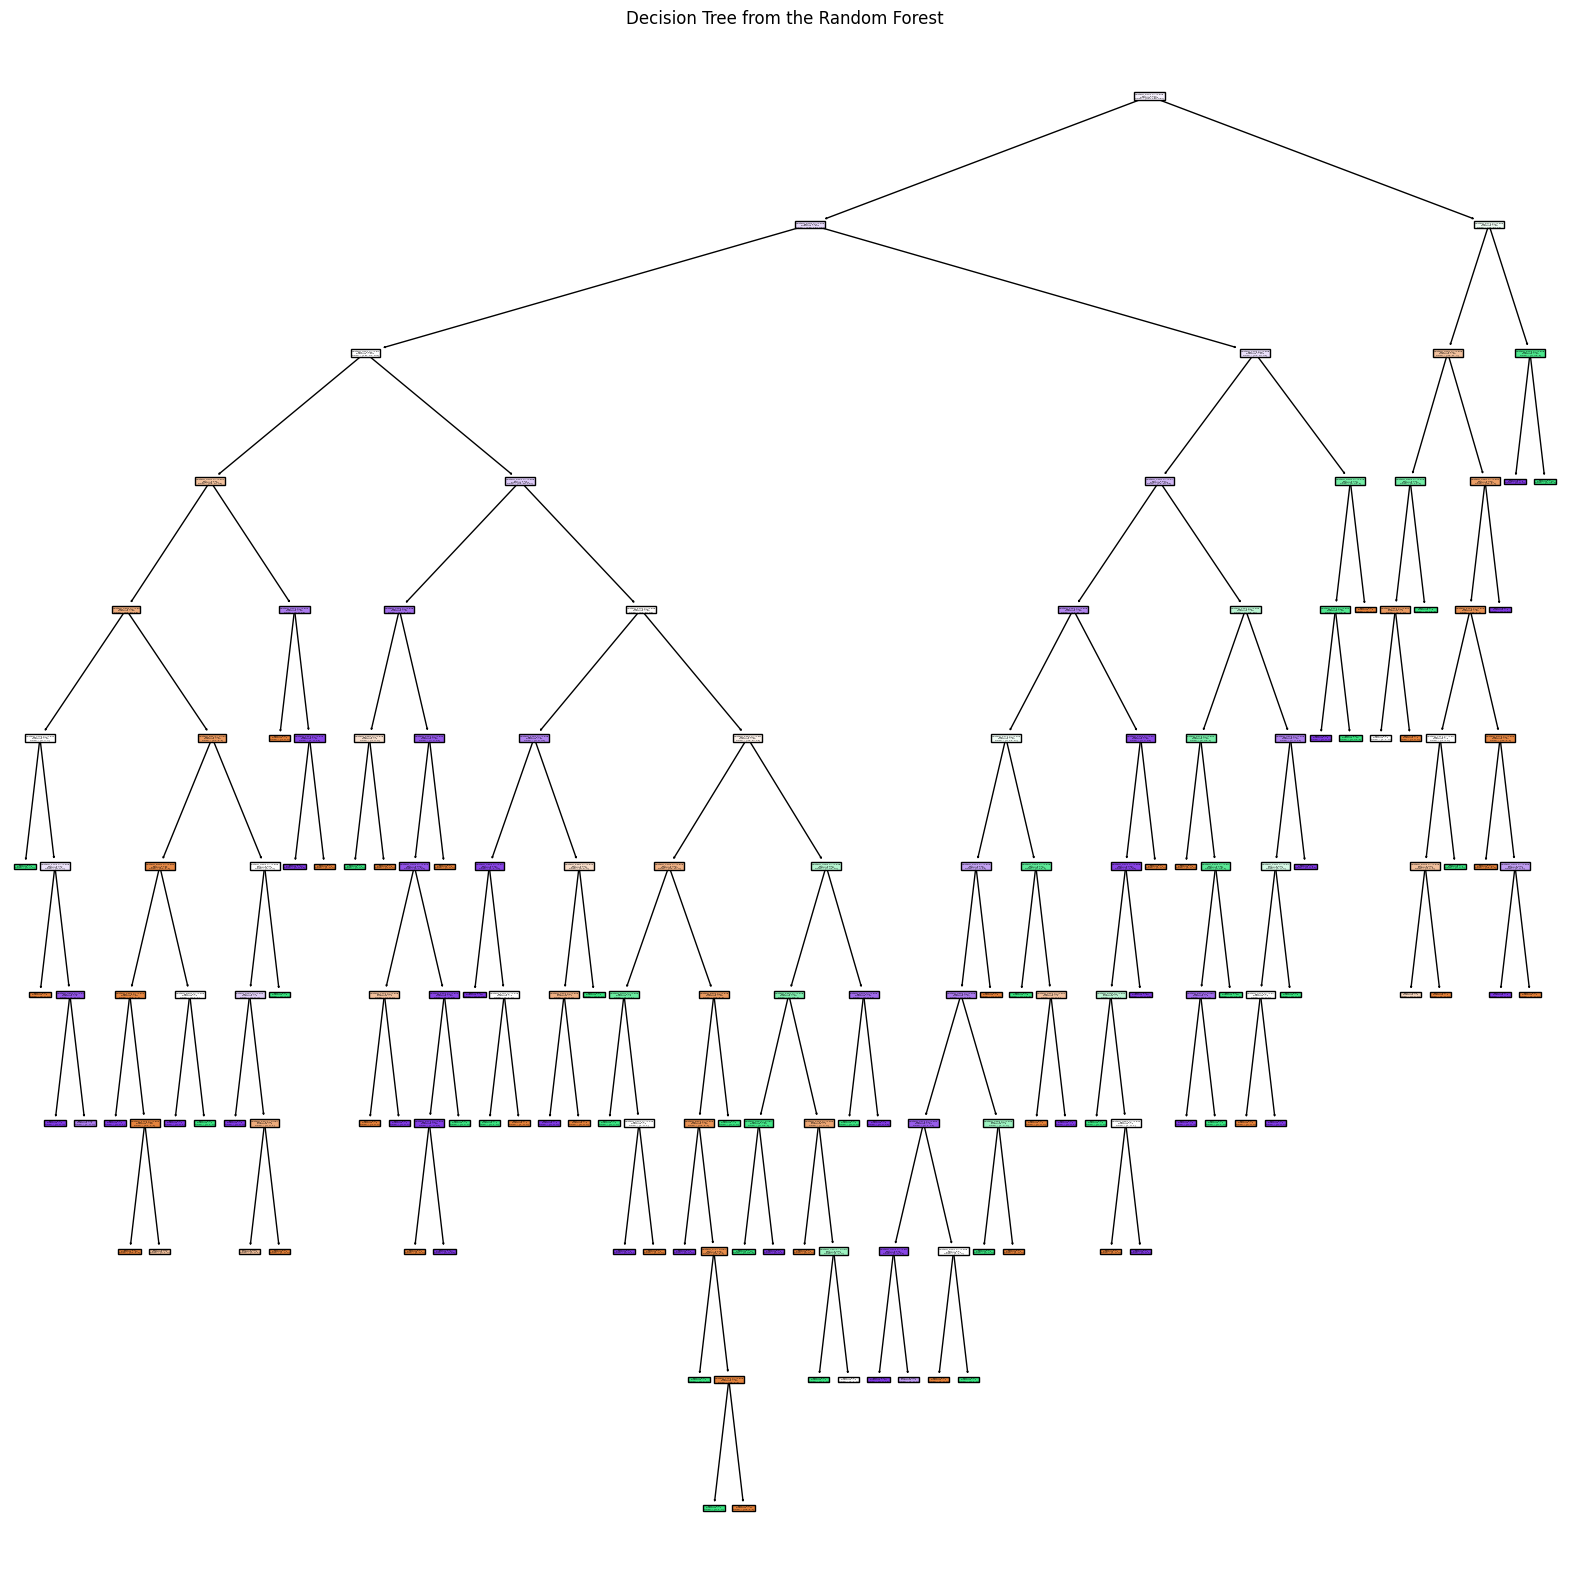

In [32]:
import joblib
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from skimage.feature import hog
import numpy as np

# Load the Random Forest model from the saved .pkl file
loaded_rf_model = joblib.load('/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_2_random_forest_model.pkl')

# Display the model summary (number of trees and other parameters)
print(f"Number of trees in the Random Forest: {len(loaded_rf_model.estimators_)}")
print(f"Parameters of the Random Forest: {loaded_rf_model.get_params()}")

# Use a sample image to determine the number of features
sample_image = np.zeros((128, 128))  # Use a dummy image of the same size as used in training
sample_hog_features = hog(sample_image, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')
num_features = len(sample_hog_features)
print(f"Number of features: {num_features}")

# Generate feature names
feature_names = [f'feature_{i}' for i in range(num_features)]

# Visualize one of the decision trees from the Random Forest
plt.figure(figsize=(20, 20))
plot_tree(loaded_rf_model.estimators_[0], filled=True, feature_names=feature_names)
plt.title("Decision Tree from the Random Forest")
plt.show()


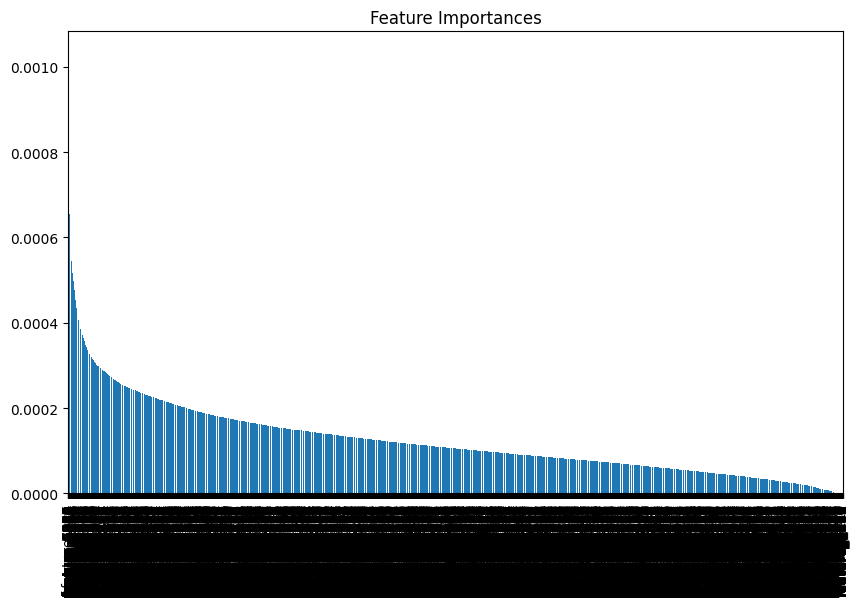

In [33]:
import joblib
import matplotlib.pyplot as plt
import numpy as np

# Load the Random Forest model from the saved .pkl file
loaded_rf_model = joblib.load('/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_2_random_forest_model.pkl')

# Extract feature importances
feature_importances = loaded_rf_model.feature_importances_
indices = np.argsort(feature_importances)[::-1]
num_features = len(feature_importances)

# Generate feature names
feature_names = [f'feature_{i}' for i in range(num_features)]
sorted_feature_names = [feature_names[i] for i in indices]

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(num_features), feature_importances[indices], align="center")
plt.xticks(range(num_features), sorted_feature_names, rotation=90)
plt.xlim([-1, num_features])
plt.show()


Number of trees in the Random Forest: 500
Parameters of the Random Forest: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 500, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Number of features: 8100


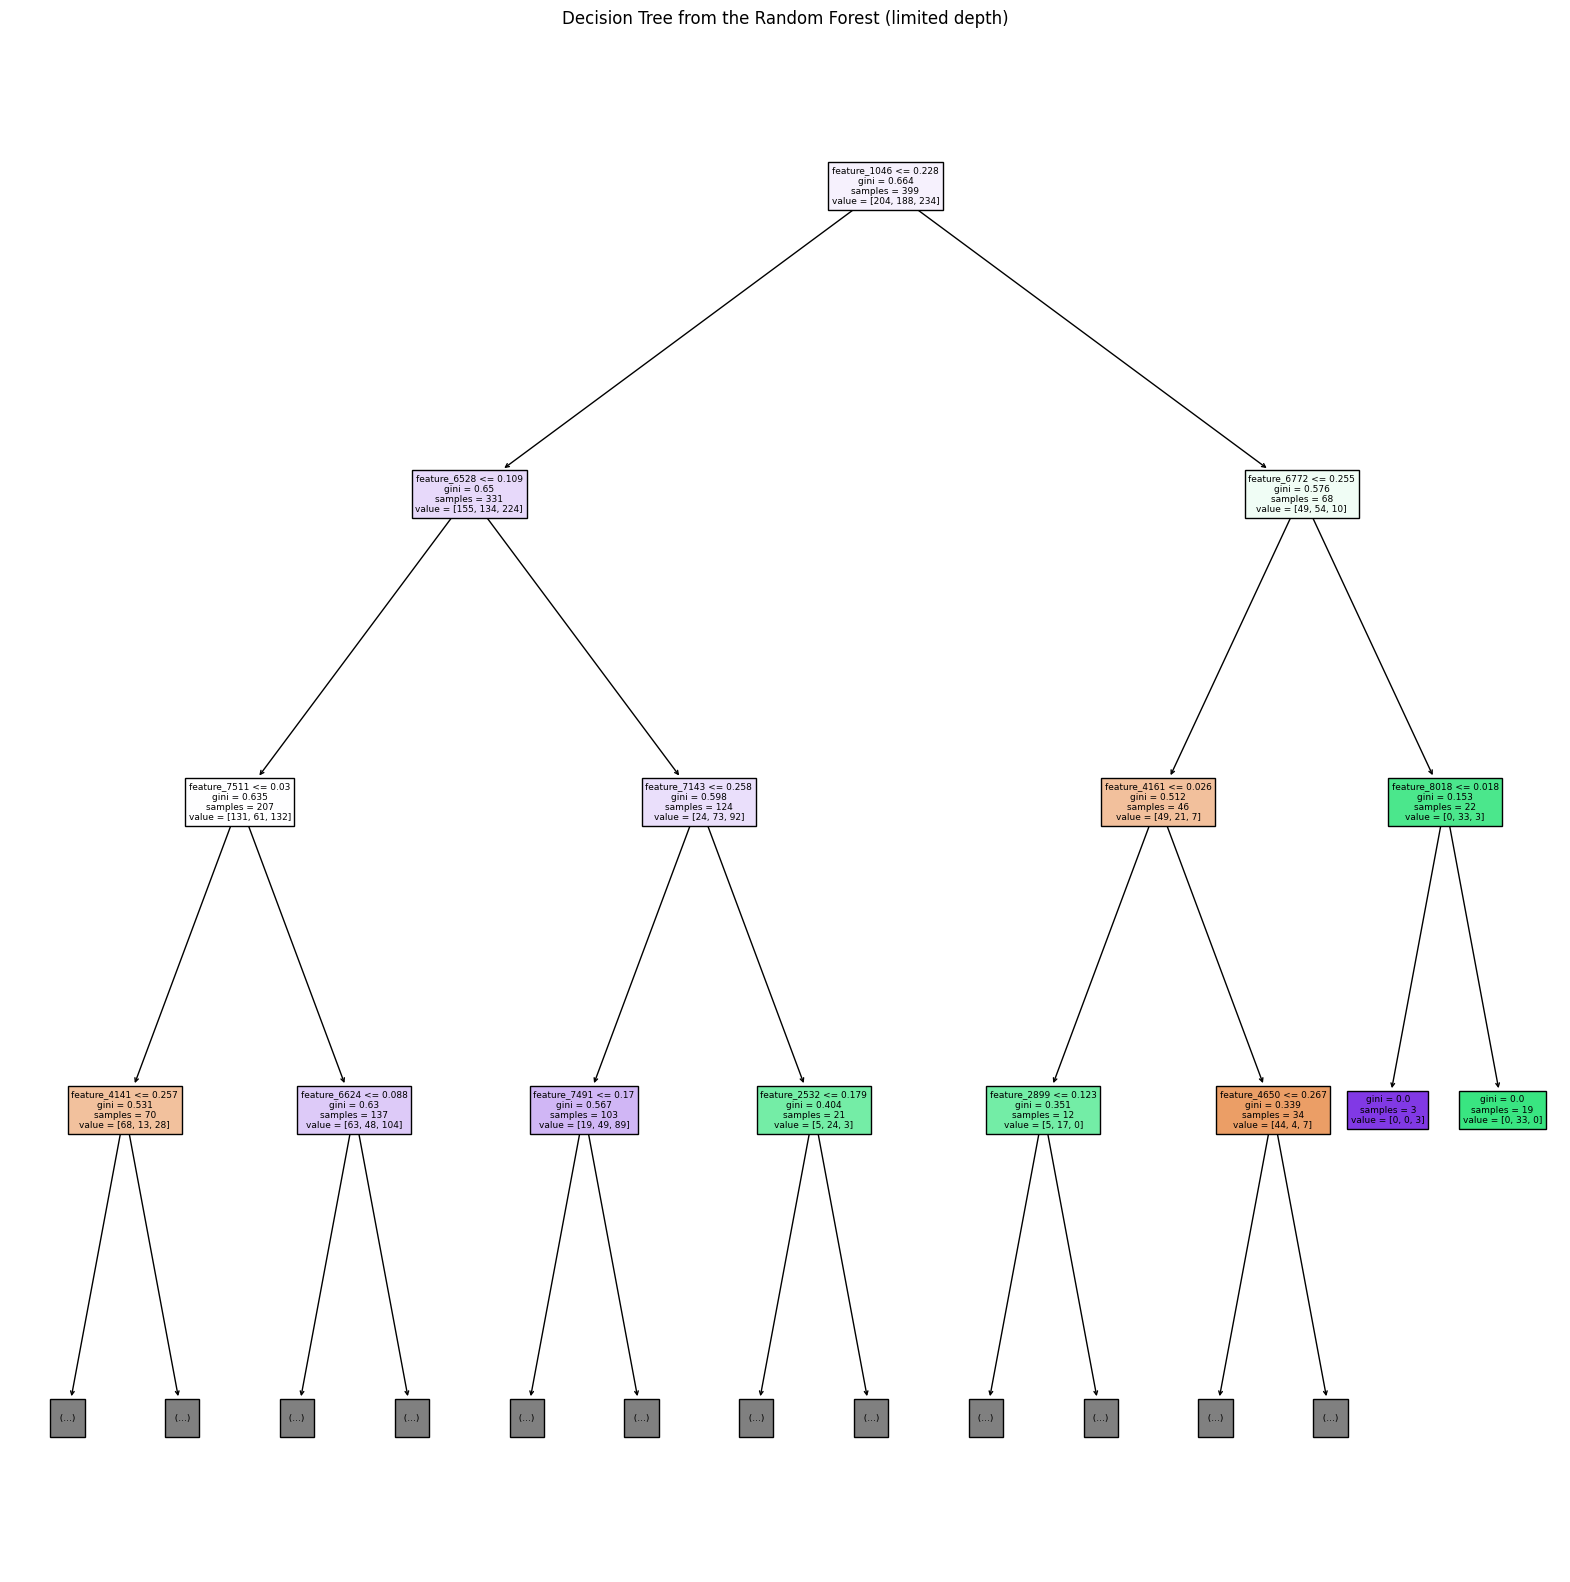

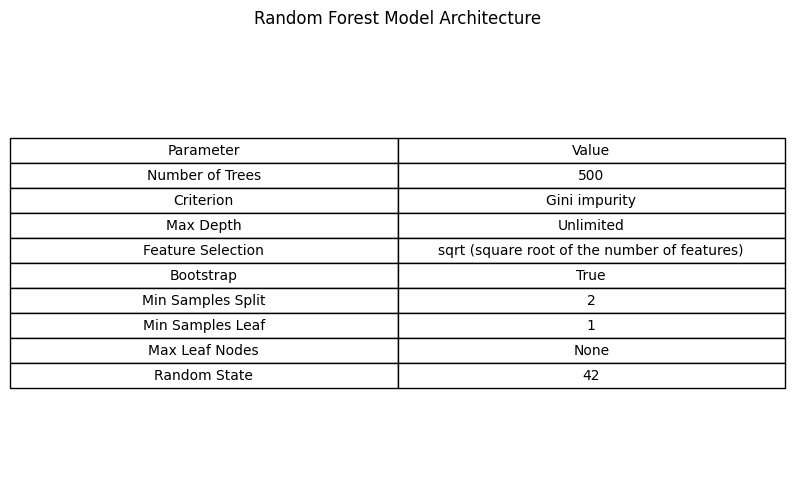

In [37]:
import joblib
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from skimage.feature import hog
import numpy as np

# Load the Random Forest model from the saved .pkl file
loaded_rf_model = joblib.load('/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_2_random_forest_model.pkl')

# Display the model summary (number of trees and other parameters)
print(f"Number of trees in the Random Forest: {len(loaded_rf_model.estimators_)}")
print(f"Parameters of the Random Forest: {loaded_rf_model.get_params()}")

# Use a sample image to determine the number of features
sample_image = np.zeros((128, 128))  # Use a dummy image of the same size as used in training
sample_hog_features = hog(sample_image, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')
num_features = len(sample_hog_features)
print(f"Number of features: {num_features}")

# Generate feature names
feature_names = [f'feature_{i}' for i in range(num_features)]

# Visualize one of the decision trees from the Random Forest with limited depth
plt.figure(figsize=(20, 20))  # Smaller figure size
plot_tree(loaded_rf_model.estimators_[0], max_depth=3, filled=True, feature_names=feature_names)
plt.title("Decision Tree from the Random Forest (limited depth)")
plt.show()

# Create a summary table of model parameters
parameters = {
    'Number of Trees': len(loaded_rf_model.estimators_),
    'Criterion': 'Gini impurity',
    'Max Depth': 'Unlimited',
    'Feature Selection': 'sqrt (square root of the number of features)',
    'Bootstrap': 'True',
    'Min Samples Split': 2,
    'Min Samples Leaf': 1,
    'Max Leaf Nodes': 'None',
    'Random State': 42
}

# Create a figure and axis for the table
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight')
ax.axis('off')

# Create table data
table_data = [[k, v] for k, v in parameters.items()]
table = ax.table(cellText=table_data, colLabels=['Parameter', 'Value'], cellLoc='center', loc='center')
table.scale(1, 1.5)  # Scale table size

# Show table plot
plt.title("Random Forest Model Architecture")
plt.show()


Number of trees in the Random Forest: 500
Parameters of the Random Forest: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 500, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Number of features: 8100


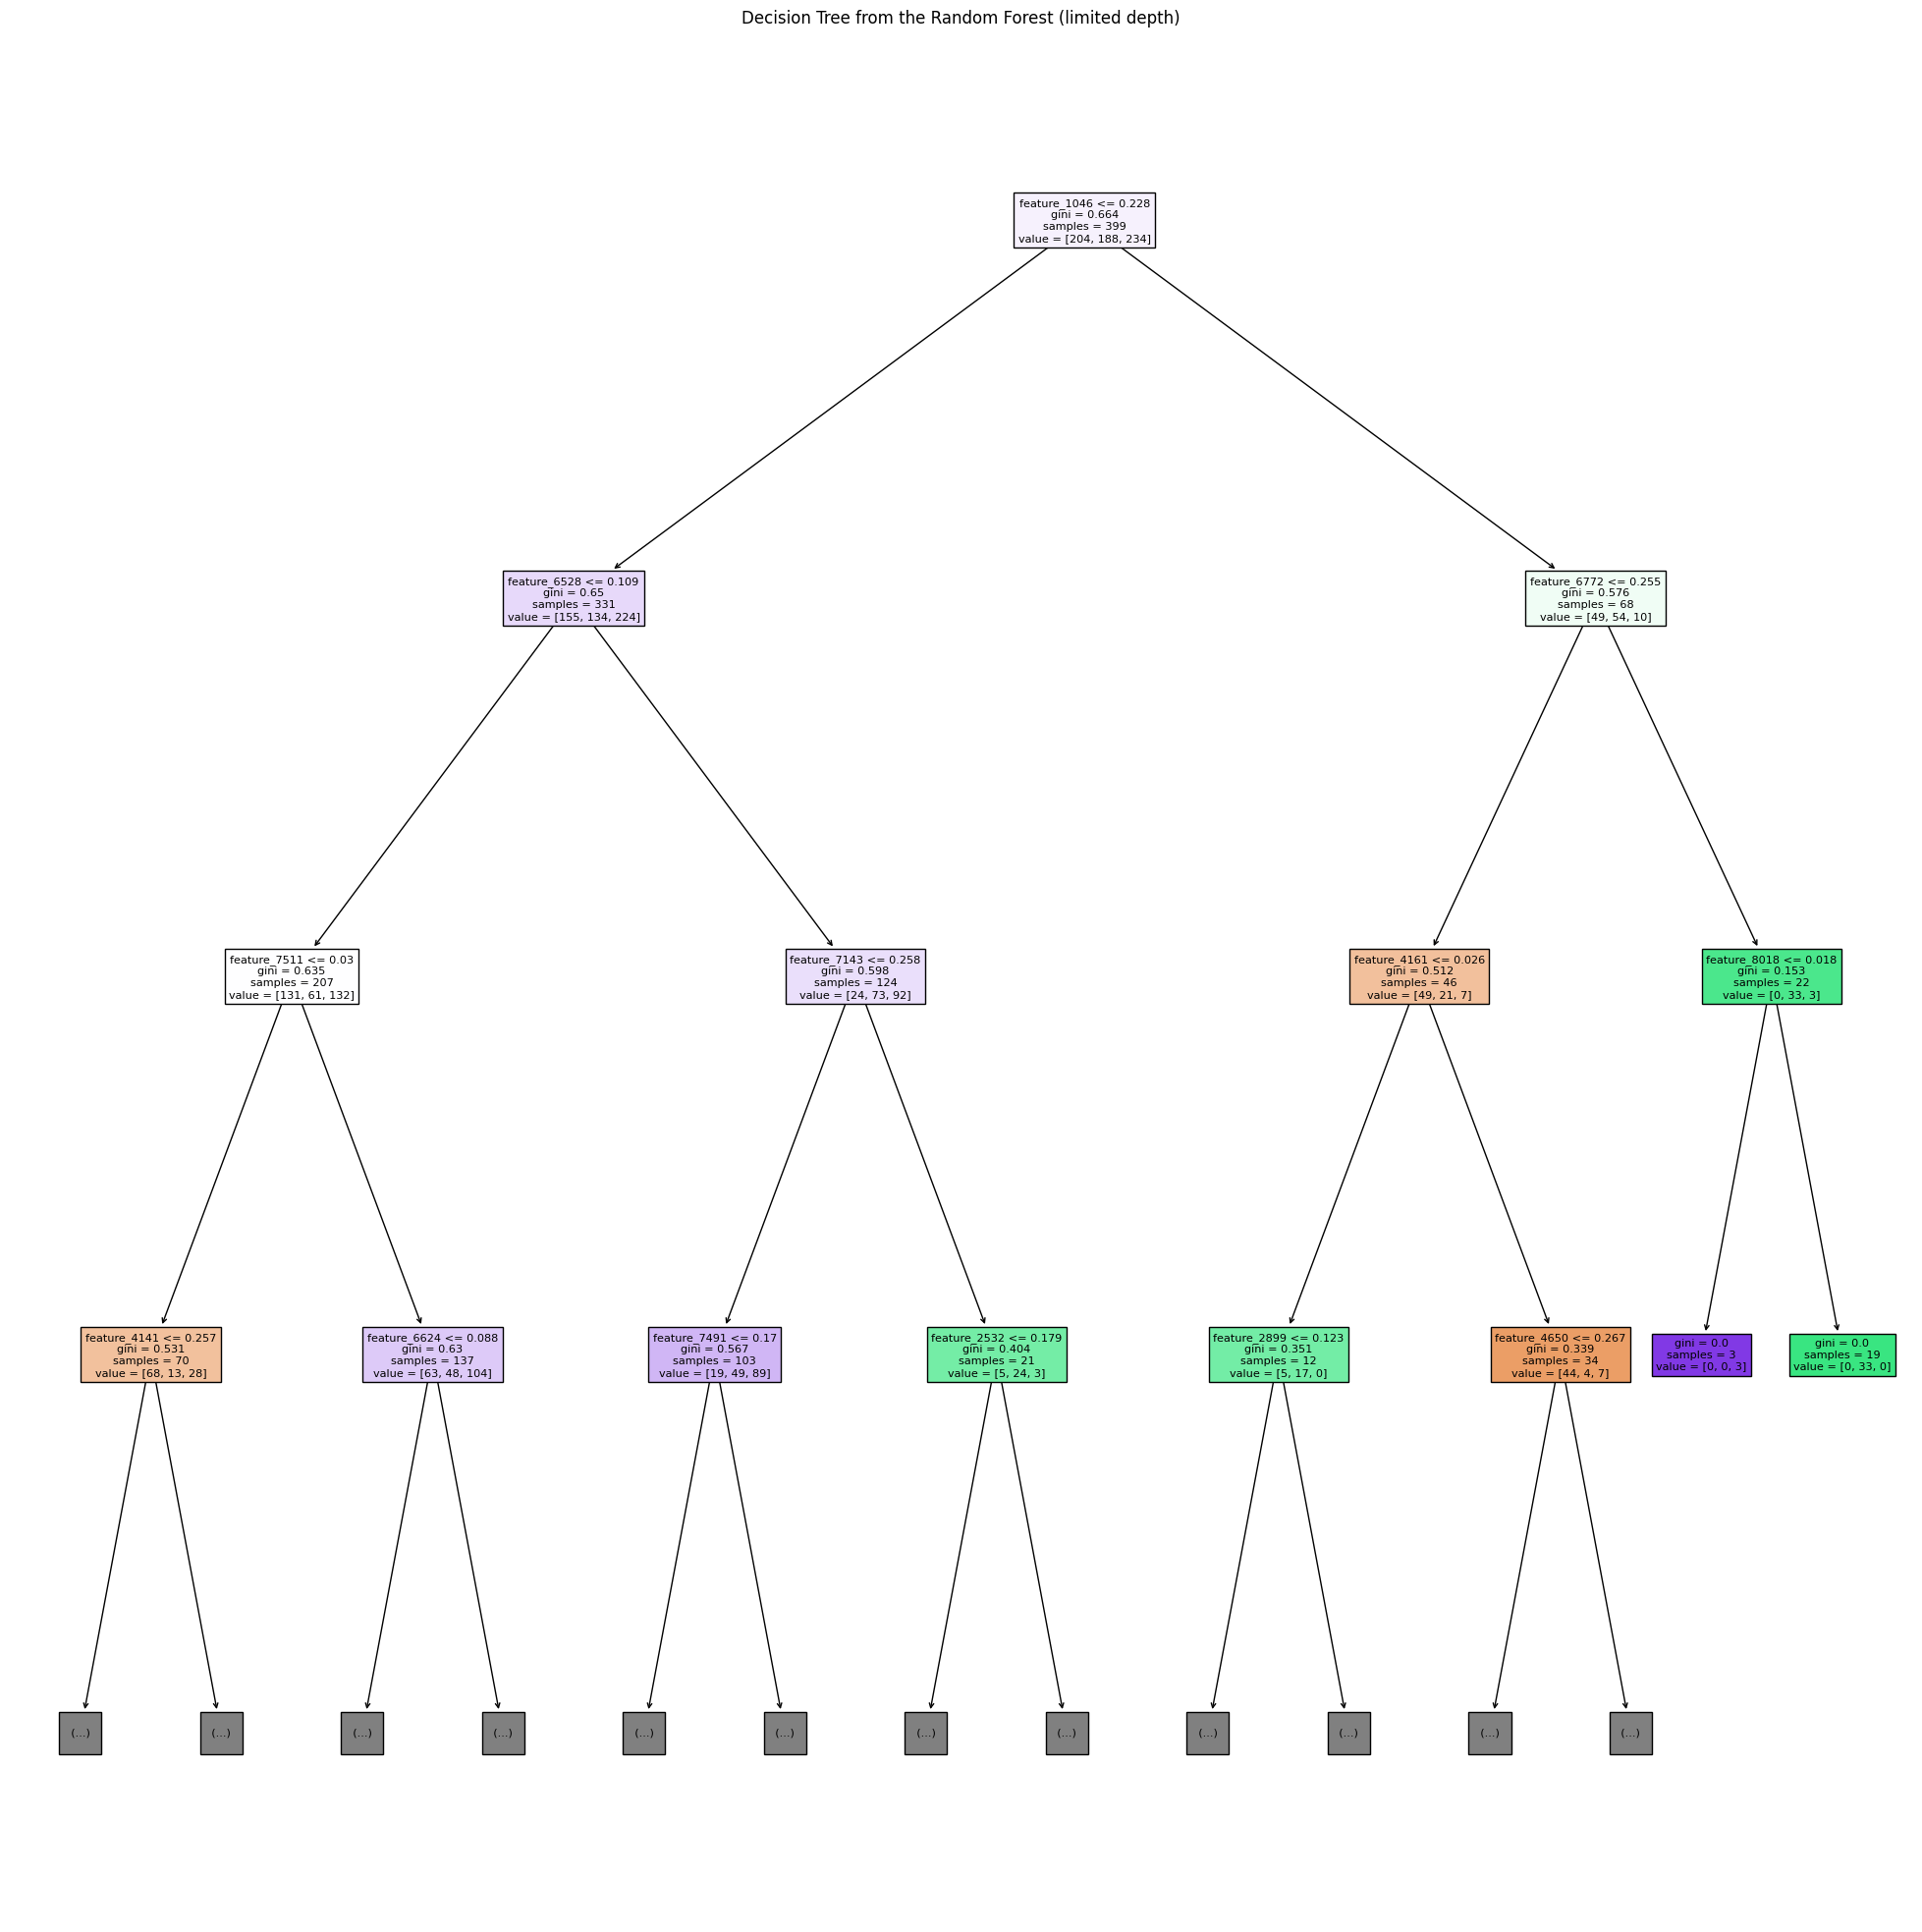

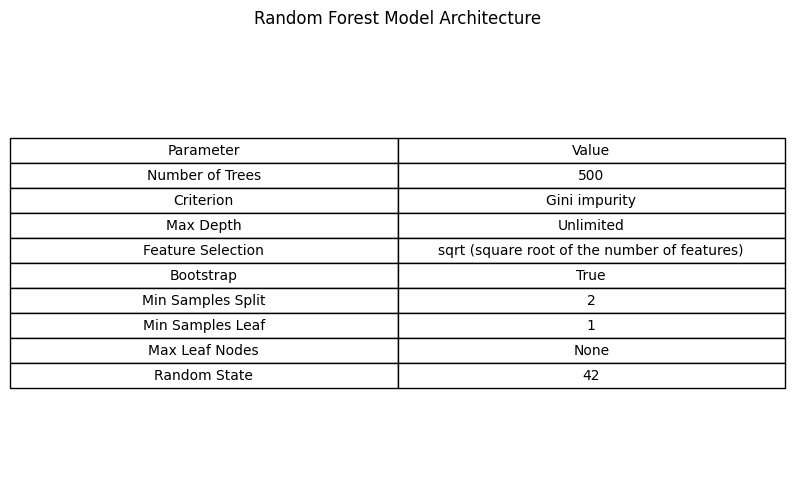

In [39]:
import joblib
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from skimage.feature import hog
import numpy as np

# Load the Random Forest model from the saved .pkl file
loaded_rf_model = joblib.load('/content/drive/MyDrive/work2/Final/Image_Models/Video_Model_2_random_forest_model.pkl')

# Display the model summary (number of trees and other parameters)
print(f"Number of trees in the Random Forest: {len(loaded_rf_model.estimators_)}")
print(f"Parameters of the Random Forest: {loaded_rf_model.get_params()}")

# Use a sample image to determine the number of features
sample_image = np.zeros((128, 128))  # Use a dummy image of the same size as used in training
sample_hog_features = hog(sample_image, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')
num_features = len(sample_hog_features)
print(f"Number of features: {num_features}")

# Generate feature names
feature_names = [f'feature_{i}' for i in range(num_features)]

# Visualize one of the decision trees from the Random Forest with limited depth and save as SVG
fig, ax = plt.subplots(figsize=(25, 25))  # Smaller figure size
plot_tree(loaded_rf_model.estimators_[0], max_depth=3, filled=True, feature_names=feature_names, ax=ax)
plt.title("Decision Tree from the Random Forest (limited depth)")
plt.savefig('/content/drive/MyDrive/work2/Final/Image_Models/decision_tree.svg', format='svg')
plt.show()

# Create a summary table of model parameters
parameters = {
    'Number of Trees': len(loaded_rf_model.estimators_),
    'Criterion': 'Gini impurity',
    'Max Depth': 'Unlimited',
    'Feature Selection': 'sqrt (square root of the number of features)',
    'Bootstrap': 'True',
    'Min Samples Split': 2,
    'Min Samples Leaf': 1,
    'Max Leaf Nodes': 'None',
    'Random State': 42
}

# Create a figure and axis for the table and save as SVG
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight')
ax.axis('off')

# Create table data
table_data = [[k, v] for k, v in parameters.items()]
table = ax.table(cellText=table_data, colLabels=['Parameter', 'Value'], cellLoc='center', loc='center')
table.scale(1, 1.5)  # Scale table size

# Save table plot as SVG
plt.title("Random Forest Model Architecture")
plt.savefig('/content/drive/MyDrive/work2/Final/Image_Models/model_parameters.svg', format='svg')
plt.show()
